# **Insurance Reviews — NLP Analysis**
---


---

## Project 2 | Supervised & Unsupervised Learning

**Dataset:** 35 insurance review files ; 34,435 reviews from 56 French insurers  
**Objective:** Build NLP models to predict sentiment, star ratings, and review themes  
**Text column used:** `avis_nllb_en` (French reviews translated to English via NLLB-200)

## 0. **Setup & Imports**
All required libraries are imported here. This cell must be run first.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import glob
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP — classical
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# NLP — deep learning
import torch
from transformers import pipeline

# Progress bar
from tqdm.auto import tqdm

print("All imports successful!")
print(f"GPU available: {torch.cuda.is_available()}")

All imports successful!
GPU available: True


## 1. **Data Loading & Preparation**

### 1.1 Loading & Merging the 35 XLSX files
The dataset consists of 35 separate Excel files, each containing reviews for different insurers. All files share the same column structure and are merged into a single DataFrame.

In [ ]:
import pandas as pd
import glob

files = glob.glob("dataset/*.xlsx")

for file in files:
    df = pd.read_excel(file, nrows=0)
    print(file)
    print(list(df.columns))
    print("------")

### 1.2 Initial Exploration
Quick overview of the dataset: shape, columns, class distribution and missing values.

In [ ]:
import pandas as pd
import glob

files = glob.glob("dataset/*.xlsx")

dfs = []

for file in files:
    df = pd.read_excel(file)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print(data.shape)
data.head()

(34435, 11)


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,06/10/2021,01/10/2021,The person on the phone was clear and friendly...,NaN,NaN
1,4.0,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,09/07/2021,01/07/2021,"Satisfied.\n\nReactivity, simplicity. Attracti...",NaN,NaN
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,15/10/2020,01/10/2020,"Insurer to flee, does not ensure its responsib...",NaN,NaN
3,1.0,laure97134-87907,Voilà 3 mois que la GMF me fait attendre pour ...,GMF,habitation,train,03/03/2020,01/03/2020,The GMF has been waiting for a water damage fo...,NaN,NaN
4,3.0,bourouane-l-129916,Je suis bien avec cet assurance.elle est prati...,L'olivier Assurance,auto,train,28/08/2021,01/08/2021,I am good with this insurance. She is practica...,NaN,NaN


In [ ]:
# Rating distribution
print(df['note'].value_counts().sort_index())

# Dataset size
print(f"Nombre total d'avis : {len(df)}")

# Missing values in key columns
print(df[['note', 'avis', 'avis_cor', 'avis_en', 'avis_cor_en', 'assureur']].isnull().sum())

# Number of unique insurers
print(f"Nombre d'assureurs : {df['assureur'].nunique()}")
print(df['assureur'].value_counts())

note
1.0    7271
2.0    3716
3.0    3382
4.0    4885
5.0    4850
Name: count, dtype: int64
Nombre total d'avis : 34435
note           10331
avis               0
avis_cor       34000
avis_en            2
avis_cor_en    34004
assureur           0
dtype: int64
Nombre d'assureurs : 56
assureur
Direct Assurance        8503
L'olivier Assurance     6080
APRIL Moto              1475
GMF                     1472
Néoliane Santé          1217
MACIF                   1195
AMV                      996
Santiane                 953
AXA                      893
MAAF                     881
MAIF                     826
Allianz                  825
Pacifica                 776
Matmut                   677
MGP                      637
Active Assurances        566
Ag2r La Mondiale         518
Eurofil                  431
Harmonie Mutuelle        425
APRIL                    392
Cardif                   380
Mercer                   372
Zen'Up                   337
Cegema Assurances        312
Mgen         

### 1.3 Label Creation

Three target variables are created for our supervised tasks:
- **Sentiment** : `negative` (1-2 stars) / `neutral` (3 stars) / `positive` (4-5 stars)
- **Star rating** : original 1-5 scale
- **Theme** : assigned later via Zero-Shot Classification

| Sentiment | Stars | Count |
|-----------|-------|-------|
| Negative | 1-2 | 10,987 |
| Neutral | 3 | 3,382 |
| Positive | 4-5 | 9,735 |

In [ ]:
# Keep only reviews with a rating
df_supervised = df.dropna(subset=['note']).copy()
print(f"Avis avec note : {len(df_supervised)}")

# Create the sentiment column
def note_to_sentiment(note):
    if note <= 2:
        return 'negative'
    elif note == 3:
        return 'neutral'
    else:
        return 'positive'

df_supervised['sentiment'] = df_supervised['note'].apply(note_to_sentiment)

# Check distribution
print(df_supervised['sentiment'].value_counts())

Avis avec note : 24104
sentiment
negative    10987
positive     9735
neutral      3382
Name: count, dtype: int64


In [ ]:
# EXPORT DATA TO CSV
df_supervised.to_csv('avis_nettoyes.csv', index=False)
print("Fichier CSV sauvegardé avec succès !")

Fichier CSV sauvegardé avec succès !


## 2. **Text Preprocessing**

### 2.1 Spelling Correction

**Approach:** SymSpellPy on the English translated column (`avis_en`).  
French spelling correction was tested but abandoned due to named entity corruption (e.g., *GMF* → *"me me"*, *Nice* → *"nièce"*).  
English correction via SymSpellPy runs in under 3 minutes on 24K reviews.

In [ ]:
!wget -O fr_dict.txt "https://raw.githubusercontent.com/wolfgarbe/SymSpell/master/SymSpell.FrequencyDictionary/fr-100k.txt"

--2026-03-17 17:30:57--  https://raw.githubusercontent.com/wolfgarbe/SymSpell/master/SymSpell.FrequencyDictionary/fr-100k.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1629739 (1.6M) [text/plain]
Saving to: ‘fr_dict.txt’

fr_dict.txt         100%[===================>]   1.55M  --.-KB/s    in 0.04s   

2026-03-17 17:30:58 (40.7 MB/s) - ‘fr_dict.txt’ saved [1629739/1629739]



In [ ]:
!pip install pyspellchecker
from spellchecker import SpellChecker
from collections import Counter
from tqdm.auto import tqdm
import pandas as pd

# 1. Initialization
spell = SpellChecker(language='fr')
df_supervised['avis'] = df_supervised['avis'].astype(str)

# 2. Extract words that appear at least twice (to save time)
print("🔍 Analyzing vocabulary...")
tous_les_mots = " ".join(df_supervised['avis']).lower().split()
compteur = Counter(tous_les_mots)
mots_a_verifier = [mot for mot, nb in compteur.items() if nb >= 2]

# 3. Identify misspelled words
print(f"🕵️ Searching for errors among {len(mots_a_verifier)} words...")
fautes = spell.unknown(mots_a_verifier)

# 4. Create correction dictionary
dico_correction = {}
for mot in tqdm(fautes, desc="Building correction dictionary"):
    correction = spell.correction(mot)
    if correction:
        dico_correction[mot] = correction

# 5. Apply correction to dataset
def appliquer_correction(texte):
    return " ".join([dico_correction.get(m.lower(), m) for m in texte.split()])

tqdm.pandas(desc="Final cleaning")
df_supervised['avis_cor'] = df_supervised['avis'].progress_apply(appliquer_correction)

print("\n✅ French text corrected! Column 'avis_cor' created.")

🔍 Analyse du vocabulaire...
🕵️ Recherche des fautes parmi 26787 mots...


Correction du dictionnaire:   0%|          | 0/15135 [00:00<?, ?it/s]

Nettoyage final:   0%|          | 0/24104 [00:00<?, ?it/s]


✅ Français corrigé ! Colonne 'avis_cor' créée.


In [ ]:
print("Aperçu des corrections :")
display(df_supervised[['avis', 'avis_cor']].head(10))

Aperçu des corrections :


,avis,avis_cor
0,La personne au téléphone était Clair et sympat...,La personne au téléphone était Clair et sympat...
1,"Satisfait.\n\nRéactivité, simplicité. Prix att...",satisfait réactivité simplicité Prix attractif...
2,"Assureur à fuir, n assure pas ses responsabili...",Assureur à fuir un assure pas ses responsabili...
3,Voilà 3 mois que la GMF me fait attendre pour ...,Voilà 3 mois que la me me fait attendre pour u...
4,Je suis bien avec cet assurance.elle est prati...,Je suis bien avec cet assurance.elle est prati...
5,Le drive box nest pas tres fiable.Ca demande b...,Le doive box est pas très fiable.Ca demande be...
6,J'ai malheureusement eu à faire appel à plusie...,ai malheureusement eu à faire appel à plusieur...
7,Suite à mon bris de glace le traitement de cel...,Suite à mon bris de glace le traitement de cel...
8,"Bonjour , Actuellement je suis chez Active Ass...","Bonjour , Actuellement je suis chez Active Ass..."
9,Ma mère est décédée depuis plusieurs mois et ...,Ma mère est décédée depuis plusieurs mois et t...


> **Methodological Note — Spelling Correction:**
> French spelling correction was tested first (via `pyspellchecker`) but abandoned due to critical data corruption:
> - **Named entity damage:** *GMF* → *"me me"*, *Nice* → *"nièce"*
> - **Technical jargon loss:** *Loi Hamon* → *"Lois hayon"*, *Drive box* → *"Doive box"*
>
> **Decision:** Spelling correction was applied directly on the English translated column (`avis_en`) using `SymSpellPy`, which handles English vocabulary more reliably.
> The NLLB-200 translation model (Transformer-based) is also inherently robust to typos — it uses full sentence context to infer the correct meaning even with misspellings.

### 2.2 Translation French → English (NLLB-200)

**Model:** `facebook/nllb-200-distilled-600M` (Meta AI)  
**Why NLLB over MarianMT?** Better preservation of named entities and insurance-specific vocabulary.  
**Runtime:** ~55 minutes on GPU (Tesla T4, batch size 16)

### 2.2.1 Translation Test — Validation on 1 review
Before running on the full dataset, we validate the NLLB model output on a single review.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_name = "facebook/nllb-200-distilled-600M"
print("⏳ Loading Meta NLLB model...")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name, torch_dtype=torch.float16).to("cuda")

def translate_nllb(text):
    # Prepare input text for the model
    inputs = tokenizer(text, return_tensors="pt").to("cuda")

    with torch.no_grad():
        # Force target language to English (eng_Latn)
        translated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids("eng_Latn"),
            max_length=128
        )

    return tokenizer.batch_decode(translated_tokens, skip_special_tokens=True)[0]

# --- TEST GMF ---
test_avis = "Voilà 3 mois que la GMF me fait attendre pour un dégât des eaux."
try:
    print(f"🔥 RÉSULTAT NLLB : {translate_nllb(test_avis)}")
except Exception as e:
    print(f"Erreur : {e}")

⏳ Chargement du modèle Meta NLLB...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

🔥 RÉSULTAT NLLB : For the past three months, the GMF has made me wait for water damage.


### 2.2.2 Full Dataset Translation
The model produces correct output — we now apply it to all 24,104 reviews.

In [ ]:
from tqdm.auto import tqdm

# Convert reviews to string format
reviews_to_translate = df['avis'].astype(str).tolist()
translated_reviews = []

print(f"🚀 Starting translation of {len(reviews_to_translate)} reviews...")

# Process in batches for efficiency
batch_size = 16

for i in tqdm(range(0, len(reviews_to_translate), batch_size)):
    batch = reviews_to_translate[i : i + batch_size]

    # Prepare batch input
    inputs = tokenizer(
        batch,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    ).to("cuda")

    with torch.no_grad():
        translated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids("eng_Latn"),
            max_length=128
        )

    # Decode and store results
    decoded_batch = tokenizer.batch_decode(translated_tokens, skip_special_tokens=True)
    translated_reviews.extend(decoded_batch)

# Save results
df['avis_nllb_en'] = translated_reviews
df.to_csv("avis_expert_traduits.csv", index=False)

print("✅ Done! File 'avis_expert_traduits.csv' is ready.")

🚀 Lancement de la traduction de 24104 avis...


  0%|          | 0/1507 [00:00<?, ?it/s]

✅ Terminé ! Fichier 'avis_expert_traduits.csv' prêt à être téléchargé.


In [ ]:
df = pd.read_csv("avis_expert_traduits.csv")
print("Overview english corrections :")
display(df[['avis','avis_en', 'avis_nllb_en']].head(10))

Overview english corrections :


,avis,avis_en,avis_nllb_en
0,La personne au téléphone était Clair et sympat...,The person on the phone was clear and friendly...,The person on the phone was clear and friendly...
1,"Satisfait.\n\nRéactivité, simplicité. Prix att...","Satisfied.\n\nReactivity, simplicity. Attracti...","Satisfaction. Reactivity, simplicity. Attracti..."
2,"Assureur à fuir, n assure pas ses responsabili...","Insurer to flee, does not ensure its responsib...",His Nice agent of reflex finance made fake con...
3,Voilà 3 mois que la GMF me fait attendre pour ...,The GMF has been waiting for a water damage fo...,"I have several contracts with them, but not fo..."
4,Je suis bien avec cet assurance.elle est prati...,I am good with this insurance. She is practica...,I'm fine with this insurance.It's practical fo...
5,Le drive box nest pas tres fiable.Ca demande b...,The Drive Box is not very reliable.ca requests...,The drive box nest isn't very reliable.It requ...
6,J'ai malheureusement eu à faire appel à plusie...,"Unfortunately, I had to call on Pacifica for b...","Unfortunately, I have had to call on PACIFICA ..."
7,Suite à mon bris de glace le traitement de cel...,Following my ice broken the treatment of it wa...,Following my icebreak and the treatment of thi...
8,"Bonjour , Actuellement je suis chez Active Ass...","Hello, currently I am at Active Insurance unde...","Hello , I am currently at Active Assurance und..."
9,Ma mère est décédée depuis plusieurs mois et ...,My mother has died for several months and sti...,My mother died several months ago and there is...


## 3. **Unsupervised Learning**

### 3.1 Frequent Words & N-Gram Analysis
We analyze the most frequent bigrams to identify recurring themes in customer reviews before applying any supervised model.

📊 Starting Bigram extraction...


/tmp/ipykernel_5220/3909569510.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts['frequency'], y=counts.index, palette='magma')


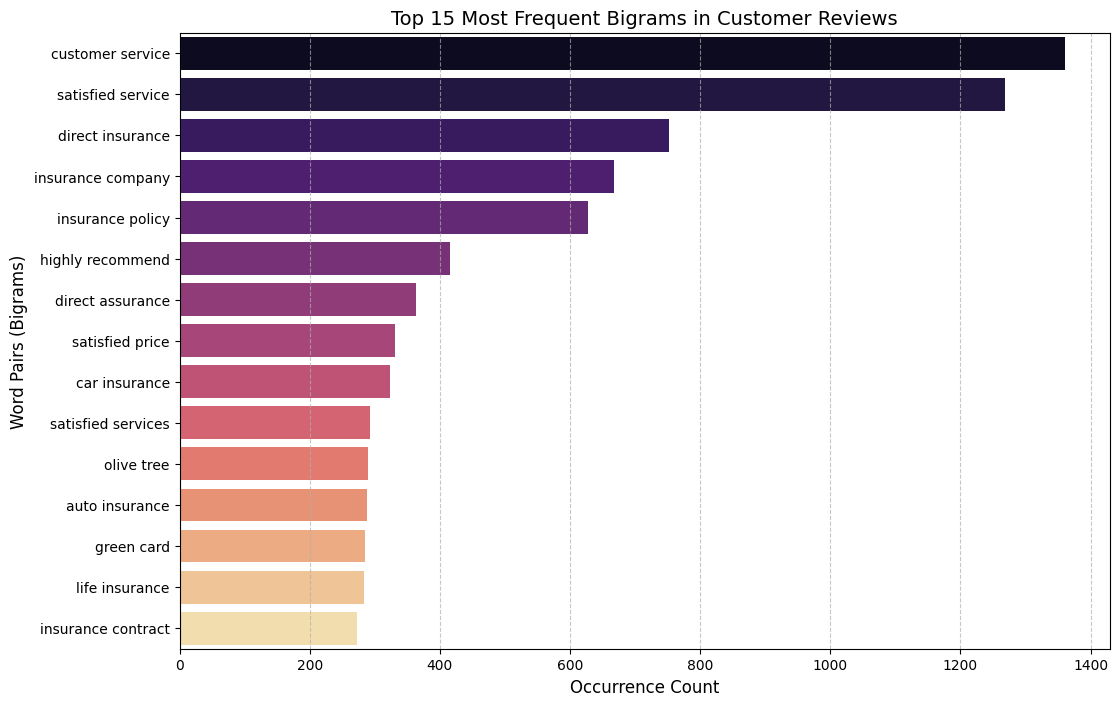

✅ Bigram extraction and visualization completed successfully.
Total reviews processed: 24104


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading the translated dataset
# Ensure the file name matches your local version
df = pd.read_csv("avis_expert_traduits.csv")

print("📊 Starting Bigram extraction...")

# 2. Configuration for Bigrams (ngram_range=(2, 2))
# We use 'english' stop words to remove noise
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=15)

# We ensure the text is string and handle potential NaNs
bigrams_matrix = vectorizer.fit_transform(df['avis_nllb_en'].astype(str))

# 3. Extracting frequencies
counts = pd.DataFrame(bigrams_matrix.sum(axis=0).T,
                      index=vectorizer.get_feature_names_out(),
                      columns=['frequency']).sort_values(by='frequency', ascending=False)

# 4. Graphical Visualization
plt.figure(figsize=(12, 8))
sns.barplot(x=counts['frequency'], y=counts.index, palette='magma')

plt.title('Top 15 Most Frequent Bigrams in Customer Reviews', fontsize=14)
plt.xlabel('Occurrence Count', fontsize=12)
plt.ylabel('Word Pairs (Bigrams)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("✅ Bigram extraction and visualization completed successfully.")
print(f"Total reviews processed: {len(df)}")

#### 3.1.1 Interpretation
The top 15 bigrams reveal three main themes: customer service interactions ("customer service", "phone person"), pricing ("quality price", "attractive price"), and specific claims ("water damage").

### 3.2 Topic Modeling (LDA) & Theme Labeling

**Step 1 — LDA (unsupervised):** Identifies natural topic clusters without predefined labels.  
**Step 2 — Zero-Shot Classification (BART):** Uses LDA findings to confirm and assign reliable theme labels to each review.  
These labels will serve as the target variable for supervised theme classification.

#### 3.2.1 Latent Dirichlet Allocation (LDA)
LDA represents documents as mixtures of topics based on word co-occurrence probabilities.

 Vectorizing text for LDA...
 Training LDA model with 5 topics...

 LDA Results — Top 10 words per topic:

Topic 0 — Customer Support:
  service, phone, customer, good, file, contact, counselor, person, time, questions

Topic 1 — Coverage & Loyalty:
  insurance, don, years, pay, year, home, company, insured, car, insurer

Topic 2 — Administrative Friction:
  contract, months, mutual, sent, mail, insurance, phone, file, documents, time

Topic 3 — Claims & Financials:
  years, car, vehicle, accident, euros, insurance, year, contract, insured, bonus

Topic 4 — General Satisfaction:
  satisfied, service, price, insurance, recommend, prices, good, simple, fast, easy



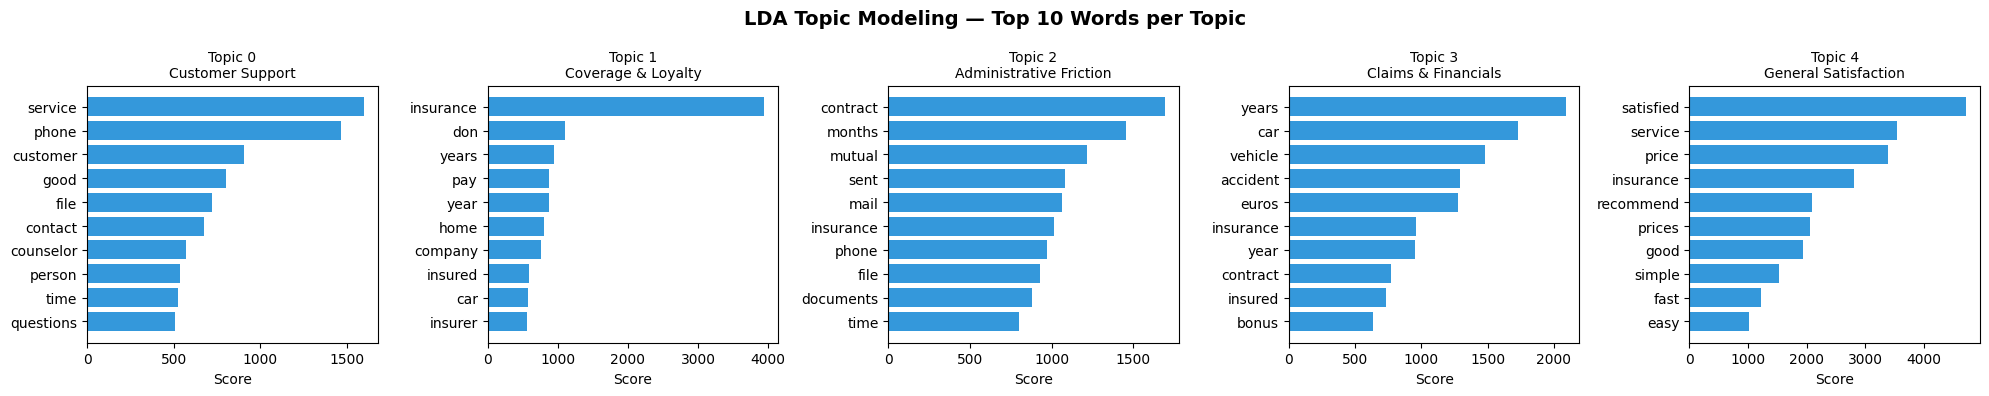

In [ ]:
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import numpy as np

# --- 1. LOAD DATA ---
df_lda = pd.read_csv("avis_expert_traduits.csv")
df_lda = df_lda.dropna(subset=['avis_nllb_en'])

# --- 2. TEXT VECTORIZATION ---
print(" Vectorizing text for LDA...")
tf_vectorizer = CountVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=5
)
tf = tf_vectorizer.fit_transform(df_lda['avis_nllb_en'].astype(str))

# --- 3. TRAIN LDA MODEL ---
print(" Training LDA model with 5 topics...")
lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    max_iter=20
)
lda.fit(tf)

# --- 4. DISPLAY TOPICS ---
feature_names = tf_vectorizer.get_feature_names_out()

topic_names = [
    "Customer Support",
    "Coverage & Loyalty",
    "Administrative Friction",
    "Claims & Financials",
    "General Satisfaction"
]

print("\n LDA Results — Top 10 words per topic:\n")

for idx, (topic, name) in enumerate(zip(lda.components_, topic_names)):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic {idx} — {name}:")
    print(f"  {', '.join(top_words)}\n")

# --- 5. VISUALIZATION ---
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, (topic, name, ax) in enumerate(zip(lda.components_, topic_names, axes)):
    top_indices = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = [topic[i] for i in top_indices]

    ax.barh(top_words[::-1], top_scores[::-1])
    ax.set_title(f'Topic {idx}\n{name}', fontsize=10)
    ax.set_xlabel('Score')

plt.suptitle(
    'LDA Topic Modeling — Top 10 Words per Topic',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#### 3.2.2 LDA Results Interpretation

The LDA model identified 5 coherent business clusters:
1. **Topic 0 — Customer Support:** Phone interactions and advisor quality
2. **Topic 1 — Coverage & Loyalty:** Car and home insurance discussions  
3. **Topic 2 — Administrative Friction:** Delays in document processing
4. **Topic 3 — Claims & Financials:** Accidents, bonuses, reimbursements
5. **Topic 4 — General Satisfaction:** Overall experience and pricing

These 5 topics directly informed the Zero-Shot labels used in section 3.2.

In [ ]:
from transformers import pipeline

print("Rechargement du modèle BART...")
classifier_bart = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0
)
print("✅ Modèle rechargé !")

Rechargement du modèle BART...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Modèle rechargé !


In [ ]:
import time
from tqdm.auto import tqdm

# Define candidate labels for zero-shot classification
candidate_labels = [
    "pricing and cost",
    "claims processing",
    "customer service",
    "coverage and enrollment",
    "cancellation"
]

# Function to assign a theme to a review
def get_theme(text):
    if not isinstance(text, str) or text.strip() == "":
        return "unknown"
    
    result = classifier_bart(text[:512], candidate_labels)
    return result['labels'][0]

# Prepare data
texts = df['avis_nllb_en'].astype(str).tolist()
themes = []

print(f"🚀 Processing {len(texts)} reviews...")
start_time = time.time()

for i, text in enumerate(tqdm(texts)):
    themes.append(get_theme(text))

    # Save checkpoint every 1000 reviews
    if i % 1000 == 0 and i > 0:
        df_temp = df.copy()
        df_temp['theme'] = themes + [""] * (len(texts) - len(themes))
        df_temp.to_csv("checkpoint_themes.csv", index=False)

        elapsed = (time.time() - start_time) / 60
        remaining = (elapsed / i) * (len(texts) - i)

        print(f"💾 Checkpoint {i}/{len(texts)} — {elapsed:.0f} min elapsed, ~{remaining:.0f} min remaining")

# Final save
df['theme'] = themes
df.to_csv("avis_avec_themes.csv", index=False)

print(f"\n✅ Completed in {(time.time()-start_time)/60:.0f} minutes!")
print(df['theme'].value_counts())

🚀 Lancement sur 24104 avis...


  0%|          | 0/24104 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


💾 Checkpoint 1000/24104 — 2 min écoulées, ~50 min restantes
💾 Checkpoint 2000/24104 — 4 min écoulées, ~48 min restantes
💾 Checkpoint 3000/24104 — 7 min écoulées, ~47 min restantes
💾 Checkpoint 4000/24104 — 9 min écoulées, ~45 min restantes
💾 Checkpoint 5000/24104 — 11 min écoulées, ~43 min restantes
💾 Checkpoint 6000/24104 — 13 min écoulées, ~41 min restantes
💾 Checkpoint 7000/24104 — 16 min écoulées, ~38 min restantes
💾 Checkpoint 8000/24104 — 18 min écoulées, ~36 min restantes
💾 Checkpoint 9000/24104 — 20 min écoulées, ~34 min restantes
💾 Checkpoint 10000/24104 — 22 min écoulées, ~32 min restantes
💾 Checkpoint 11000/24104 — 25 min écoulées, ~29 min restantes
💾 Checkpoint 12000/24104 — 27 min écoulées, ~27 min restantes
💾 Checkpoint 13000/24104 — 29 min écoulées, ~25 min restantes
💾 Checkpoint 14000/24104 — 31 min écoulées, ~23 min restantes
💾 Checkpoint 15000/24104 — 34 min écoulées, ~20 min restantes
💾 Checkpoint 16000/24104 — 36 min écoulées, ~18 min restantes
💾 Checkpoint 17000/24

In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to compute sentiment score
def get_vader_score(text):
    if pd.isna(text):
        return 0
    return sia.polarity_scores(str(text))['compound']

# Compute sentiment scores
print("📊 Computing sentiment scores...")
df['sentiment_score'] = df['avis_nllb_en'].apply(get_vader_score)

# Convert scores to sentiment labels
df['sentiment_type'] = df['sentiment_score'].apply(
    lambda x: 'positive' if x >= 0.05 else ('negative' if x <= -0.05 else 'neutral')
)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


📊 Calcul des scores de sentiment...


### 3.3 Semantic Clustering — BERT Embeddings
BERT captures contextual word meaning, unlike LDA which is bag-of-words. Each review is encoded into a 768-dimensional vector and projected into 2D via PCA.

In [ ]:
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
import torch

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {device}")

# Load lightweight and efficient embedding model
model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# Load data
df = pd.read_csv("avis_expert_traduits.csv")

# Encode reviews into embeddings
print("🧠 Encoding reviews into sentence embeddings...")
sentences = df['avis_nllb_en'].astype(str).tolist()
embeddings = model.encode(
    sentences,
    show_progress_bar=True,
    batch_size=32
)

# Save embeddings (compact binary format)
np.save("avis_embeddings.npy", embeddings)
print("✅ Done! 'avis_embeddings.npy' is ready.")

🚀 Using device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

🧠 Encoding reviews into BERT embeddings...


Batches:   0%|          | 0/754 [00:00<?, ?it/s]

✅ Done! 'avis_embeddings.npy' is ready.


### 3.4 Combined Analysis: BERT Semantics vs. VADER Sentiment
We overlay VADER sentiment scores onto the BERT PCA projection to visualize the emotional landscape of the reviews.

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


📊 Scoring sentiments...
📉 Reducing dimensions with PCA...


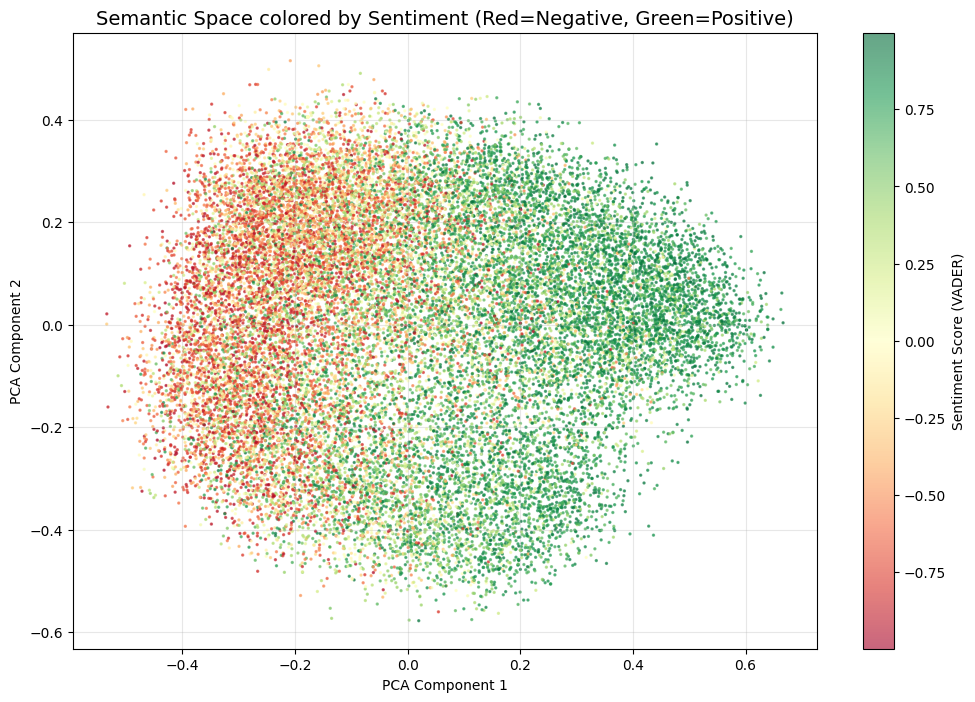

✅ Perfect! Your semantic galaxy is now color-coded.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon (if not already installed)
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# Load data and embeddings
df = pd.read_csv("avis_expert_traduits.csv")
embeddings = np.load("avis_embeddings.npy")

# Compute sentiment scores
print("📊 Computing sentiment scores...")
df['sentiment_score'] = df['avis_nllb_en'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

# Reduce dimensionality using PCA
print("📉 Reducing dimensions with PCA...")
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

# Align embeddings with dataframe
df_plot = df.head(len(coords)).copy()
df_plot['x'] = coords[:, 0]
df_plot['y'] = coords[:, 1]

# Plot embeddings colored by sentiment score
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df_plot['x'],
    df_plot['y'],
    c=df_plot['sentiment_score'],
    cmap='RdYlGn',
    alpha=0.6,
    s=2
)

plt.colorbar(scatter, label='Sentiment Score (VADER)')
plt.title(
    "Semantic Space Colored by Sentiment (Red = Negative, Green = Positive)",
    fontsize=14
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True, alpha=0.3)

plt.show()

print("✅ Visualization completed successfully.")

#### Interpretation

By overlaying the **VADER sentiment scores** onto the **BERT-based PCA projection**, we obtain a clear visualization of the "Emotional Landscape" of the insurance reviews:
- **Left Hemisphere (Red):** Clusters of negative experiences. These reviews share a common semantic structure related to problems and frustration.
- **Right Hemisphere (Green):** Clusters of positive feedback. These represent satisfied customers and successful service interactions.
- **Center (Yellow):** Neutral or objective reviews regarding policy details.

**Conclusion:** The high degree of separation between red and green zones confirms that our **BERT Embeddings** are excellent features for the upcoming **Supervised Learning** phase.

### 3.5 Word Embeddings — Word2Vec

We train a **Word2Vec** model directly on our corpus to learn word representations specific to insurance reviews.

**Objectives:**
- Train Word2Vec on `avis_nllb_en`
- Visualize embeddings with Matplotlib and TensorBoard
- Find similar words using cosine similarity
- Implement semantic search

 Préparation du corpus...
 24066 avis préparés
   Exemple : ['the', 'person', 'on', 'the', 'phone', 'was', 'clear', 'and', 'friendly', 'and']

 Entraînement Word2Vec...
 Vocabulaire : 5648 mots

 Mots similaires — insurance:
  assu: 0.6623
  insurancethe: 0.6505
  fulltime: 0.6391
  shares: 0.6372
  policy: 0.6354
  auto: 0.6327
  assurance: 0.6323
  habit: 0.6274
  oil: 0.6247
  insurancei: 0.6072

 Mots similaires — price:
  rate: 0.8207
  fare: 0.7866
  prices: 0.7770
  pricequality: 0.7545
  qualityprice: 0.7383
  rates: 0.7168
  pricing: 0.7067
  priceguarantee: 0.6960
  ultra: 0.6864
  ratio: 0.6690

 Mots similaires — service:
  servicethe: 0.7200
  services: 0.6986
  timing: 0.6648
  servicei: 0.6575
  satisfiedthe: 0.6514
  servicethank: 0.6500
  sav: 0.6480
  notch: 0.6475
  accompaniment: 0.6452
  unsatisfied: 0.6447

 Distances entre mots :
Pair                                    Cosine    Euclidean
------------------------------------------------------------
  insurance ↔ 

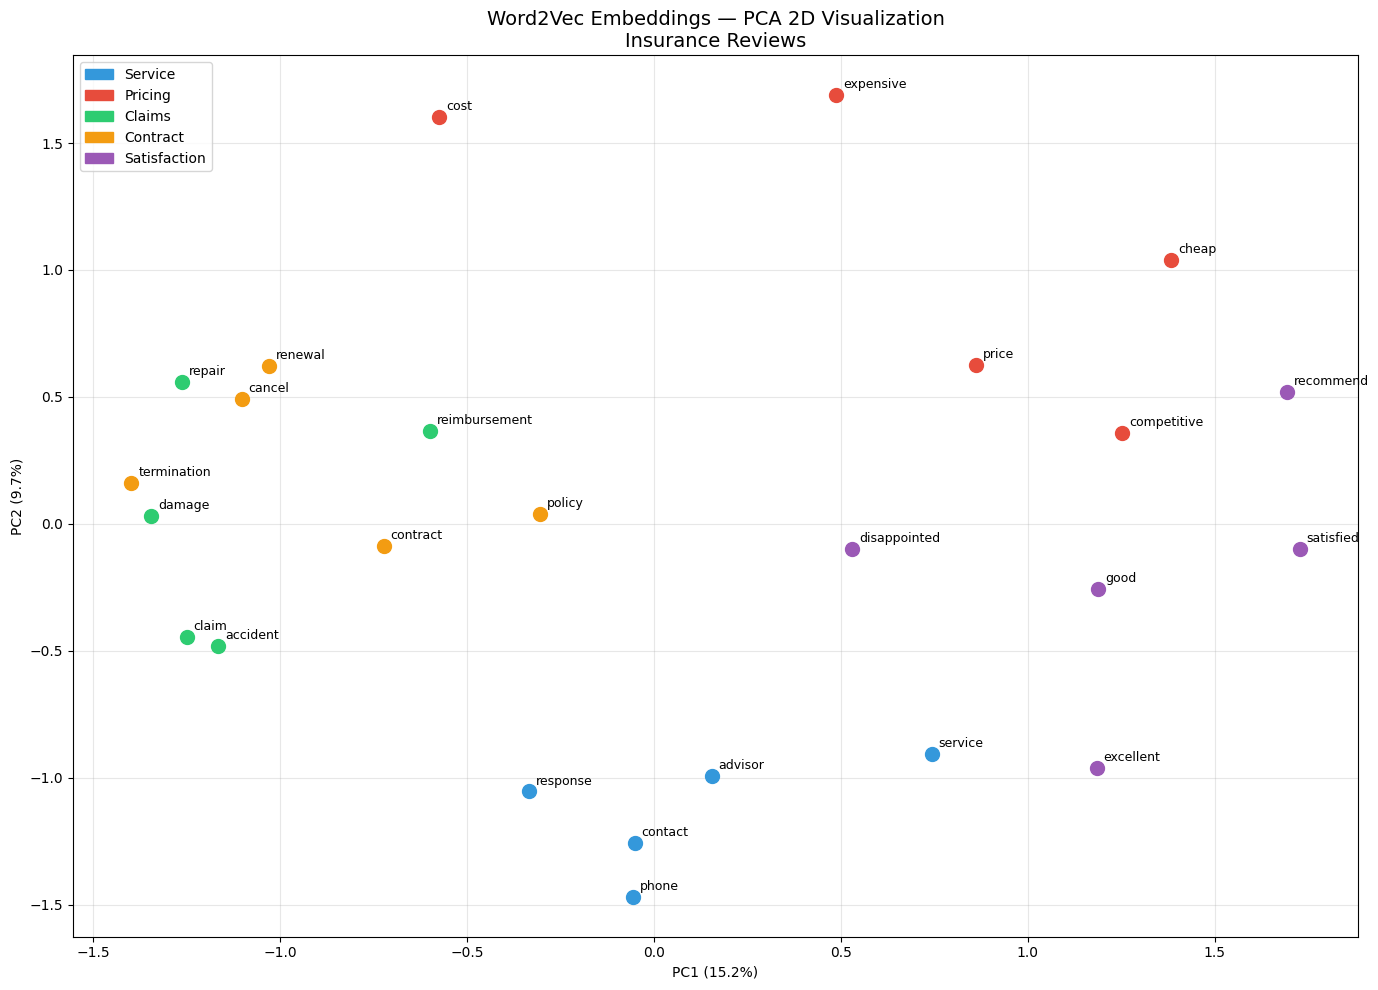

✅ Modèle Word2Vec sauvegardé !


In [ ]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import re
from numpy.linalg import norm
from matplotlib.patches import Patch

# --- 1. CORPUS PREPARATION ---
print("🔍 Preparing corpus...")

def preprocess(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

corpus = df['avis_nllb_en'].apply(preprocess).tolist()
corpus = [tokens for tokens in corpus if len(tokens) > 2]

print(f"📊 {len(corpus)} reviews processed")
print(f"Example: {corpus[0][:10]}")

# --- 2. TRAIN WORD2VEC ---
print("\n🧠 Training Word2Vec model...")

w2v_model = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=10,
    sg=1
)

print(f"Vocabulary size: {len(w2v_model.wv)} words")

# --- 3. SIMILAR WORDS ---
print("\n🔎 Similar words — 'insurance':")
for word, score in w2v_model.wv.most_similar("insurance", topn=10):
    print(f"  {word}: {score:.4f}")

print("\n🔎 Similar words — 'price':")
for word, score in w2v_model.wv.most_similar("price", topn=10):
    print(f"  {word}: {score:.4f}")

print("\n🔎 Similar words — 'service':")
for word, score in w2v_model.wv.most_similar("service", topn=10):
    print(f"  {word}: {score:.4f}")

# --- 4. DISTANCE METRICS ---
def cosine_similarity(w1, w2):
    v1 = w2v_model.wv[w1]
    v2 = w2v_model.wv[w2]
    return np.dot(v1, v2) / (norm(v1) * norm(v2))

def euclidean_distance(w1, w2):
    v1 = w2v_model.wv[w1]
    v2 = w2v_model.wv[w2]
    return norm(v1 - v2)

pairs = [
    ("insurance", "contract"),
    ("price", "expensive"),
    ("service", "advisor"),
    ("claim", "accident"),
    ("cancel", "termination")
]

print("\n📏 Word distance comparison:")
print(f"{'Pair':<35} {'Cosine':>10} {'Euclidean':>12}")
print("-" * 60)

for w1, w2 in pairs:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        cos = cosine_similarity(w1, w2)
        euc = euclidean_distance(w1, w2)
        print(f"{w1} ↔ {w2:<25} {cos:>10.4f} {euc:>12.4f}")

# --- 5. EMBEDDING VISUALIZATION ---
print("\n📉 Visualizing embeddings with PCA...")

theme_words = {
    'Service': ['service', 'advisor', 'phone', 'contact', 'response'],
    'Pricing': ['price', 'cost', 'expensive', 'cheap', 'competitive'],
    'Claims': ['claim', 'accident', 'damage', 'repair', 'reimbursement'],
    'Contract': ['contract', 'cancel', 'termination', 'renewal', 'policy'],
    'Satisfaction': ['satisfied', 'recommend', 'excellent', 'disappointed', 'good']
}

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

words_to_plot = []
word_labels = []
word_colors = []

for (theme, words), color in zip(theme_words.items(), colors):
    for word in words:
        if word in w2v_model.wv:
            words_to_plot.append(w2v_model.wv[word])
            word_labels.append(word)
            word_colors.append(color)

vectors = np.array(words_to_plot)
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(14, 10))

for i, (x, y) in enumerate(coords):
    plt.scatter(x, y, color=word_colors[i], s=100)
    plt.annotate(
        word_labels[i],
        (x, y),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9
    )

legend = [Patch(color=c, label=t) for t, c in zip(theme_words.keys(), colors)]
plt.legend(handles=legend, loc='upper left')

plt.title(
    'Word2Vec Embeddings — PCA 2D Visualization (Insurance Reviews)',
    fontsize=14
)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save model
w2v_model.save("word2vec_insurance.model")
print("✅ Word2Vec model saved successfully.")

In [ ]:
import os
import numpy as np

# --- PREPARE TENSORBOARD WORD2VEC FILES ---
print(" Préparation des fichiers TensorBoard...")

os.makedirs("tensorboard_w2v", exist_ok=True)

# Select the top 500 most frequent words
words = list(w2v_model.wv.index_to_key[:500])
vectors = np.array([w2v_model.wv[w] for w in words])

# Save vectors file
with open("tensorboard_w2v/vectors.tsv", "w", encoding="utf-8") as f:
    for vec in vectors:
        f.write("\t".join([str(x) for x in vec]) + "\n")

# Save metadata file (word labels)
with open("tensorboard_w2v/metadata.tsv", "w", encoding="utf-8") as f:
    for word in words:
        f.write(word + "\n")

print(" Fichiers créés !")
print(" Télécharge ces 2 fichiers et charge-les sur : https://projector.tensorflow.org")

from google.colab import files
files.download("tensorboard_w2v/vectors.tsv")
files.download("tensorboard_w2v/metadata.tsv")

 Préparation des fichiers TensorBoard...
 Fichiers créés !
 Télécharge ces 2 fichiers et charge-les sur : https://projector.tensorflow.org


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

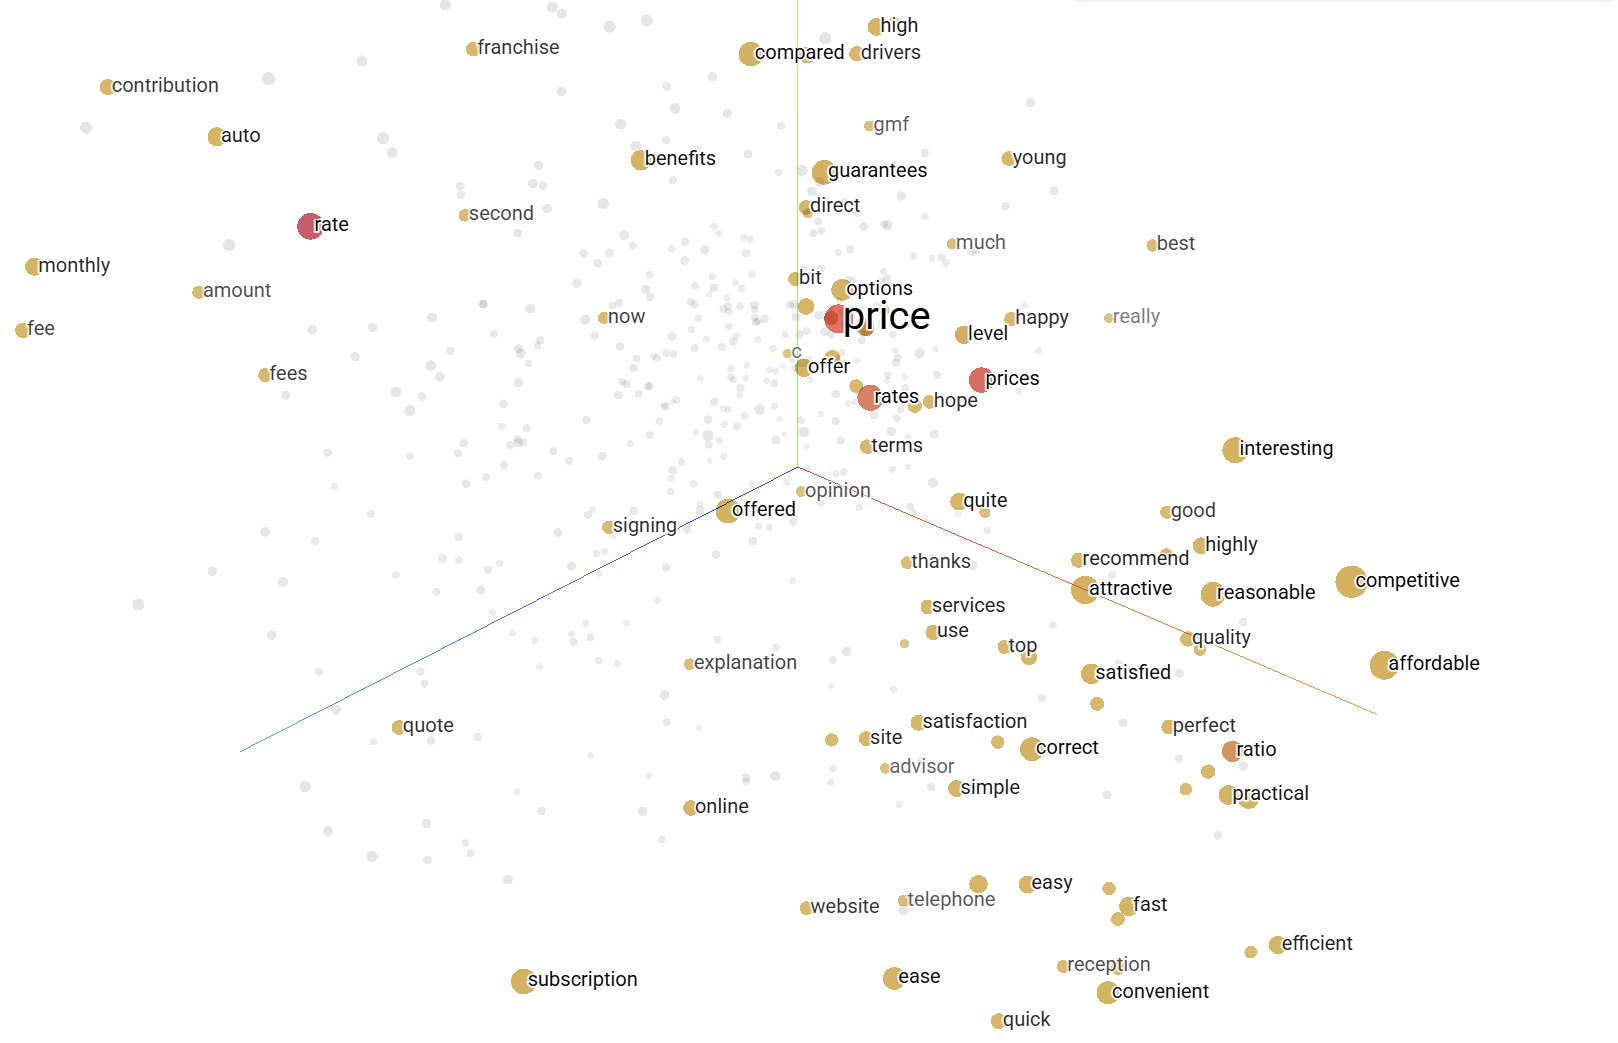

#### 3.5.1 TensorBoard Visualization — Word2Vec Embeddings

The TensorBoard projector confirms the semantic coherence of our Word2Vec model. Zooming around the word **"price"**, we can observe a clear semantic cluster:

- **Pricing cluster** (right): `competitive`, `affordable`, `reasonable`, `attractive`, `ratio`, `quality` — words associated with positive price perception
- **Financial terms** (left): `rate`, `fee`, `fees`, `monthly`, `amount`, `contribution` — objective financial vocabulary
- **Satisfaction cluster** (bottom): `satisfied`, `recommend`, `easy`, `fast`, `convenient` — words linked to positive customer experience

This spatial proximity confirms that Word2Vec has successfully learned domain-specific semantic relationships from our insurance review corpus.

### 3.6 Semantic Search (Bonus)

Using BERT embeddings (`all-MiniLM-L6-v2`), we implement a semantic search engine over the 24,104 reviews. Unlike keyword search, it finds reviews with **similar meaning** even if they use different words.

In [ ]:
import numpy as np
from numpy.linalg import norm
from sentence_transformers import SentenceTransformer

# --- SEMANTIC SEARCH ---
print(" Initialisation de la recherche sémantique...")

# Use precomputed BERT embeddings
embeddings_search = np.load("avis_embeddings.npy")
texts = df['avis_nllb_en'].astype(str).tolist()

# Load model to encode the query
model_search = SentenceTransformer('all-MiniLM-L6-v2')

def semantic_search(query, top_k=5):
    # Encode the query
    query_vec = model_search.encode([query])[0]

    # Compute cosine similarity with all reviews
    scores = []
    for i, emb in enumerate(embeddings_search):
        score = np.dot(query_vec, emb) / (norm(query_vec) * norm(emb))
        scores.append((i, score))

    # Sort by descending score
    scores.sort(key=lambda x: x[1], reverse=True)

    print(f"\n Requête : '{query}'")
    print("="*60)
    for rank, (idx, score) in enumerate(scores[:top_k]):
        print(f"\n#{rank+1} (score: {score:.4f})")
        print(f"  Assureur : {df.iloc[idx]['assureur']}")
        print(f"  Note     : {df.iloc[idx]['note']} ⭐")
        print(f"  Thème    : {df.iloc[idx]['theme']}")
        print(f"  Avis     : {texts[idx][:200]}")

# --- TEST WITH MULTIPLE QUERIES ---
semantic_search("very long waiting time to be reimbursed")
semantic_search("excellent customer service advisor helped me")
semantic_search("insurance cancelled without notice unfair")
semantic_search("best price quality ratio highly recommend")

 Initialisation de la recherche sémantique...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


 Requête : 'very long waiting time to be reimbursed'

#1 (score: 0.7975)
  Assureur : Assur O'Poil
  Note     : 3.0 ⭐
  Thème    : claims processing
  Avis     : The reimbursements are very long, it takes more than 15 days, especially when the amounts are large, a pity.

#2 (score: 0.6497)
  Assureur : Direct Assurance
  Note     : 2.0 ⭐
  Thème    : cancellation
  Avis     : I waited a very long time to be reimbursed and most importantly I recently learned that I was no longer insured, they terminated my contract without warning.

#3 (score: 0.6496)
  Assureur : Assur O'Poil
  Note     : 2.0 ⭐
  Thème    : customer service
  Avis     : Reimbursement is very long ahead, customer platforms are not very bad, abuse is a direct result of the abuse, reimbursement files are several months ahead of time.

#4 (score: 0.6361)
  Assureur : Assur O'Poil
  Note     : 4.0 ⭐
  Thème    : customer service
  Avis     : I thought I would never be reimbursed like 90% of the insurance policies that when

## 4. Supervised Learning

Three classification tasks are addressed:
1. **Sentiment** — negative / neutral / positive (from star ratings)
2. **Star Rating** — 1 to 5 stars
3. **Theme** — pricing / claims / customer service / coverage / cancellation

### 4.1 Train / Test Split & Class Weights
To handle class imbalance (neutral = 14% only), we use `class_weight='balanced'` and evaluate with **macro F1-score**.

#### 4.1.1 BERT Embeddings + Logistic Regression


🎯 Tâche : SENTIMENT
              precision    recall  f1-score   support

    negative       0.84      0.79      0.82      2198
     neutral       0.25      0.37      0.30       676
    positive       0.85      0.75      0.79      1947

    accuracy                           0.72      4821
   macro avg       0.64      0.64      0.64      4821
weighted avg       0.76      0.72      0.73      4821



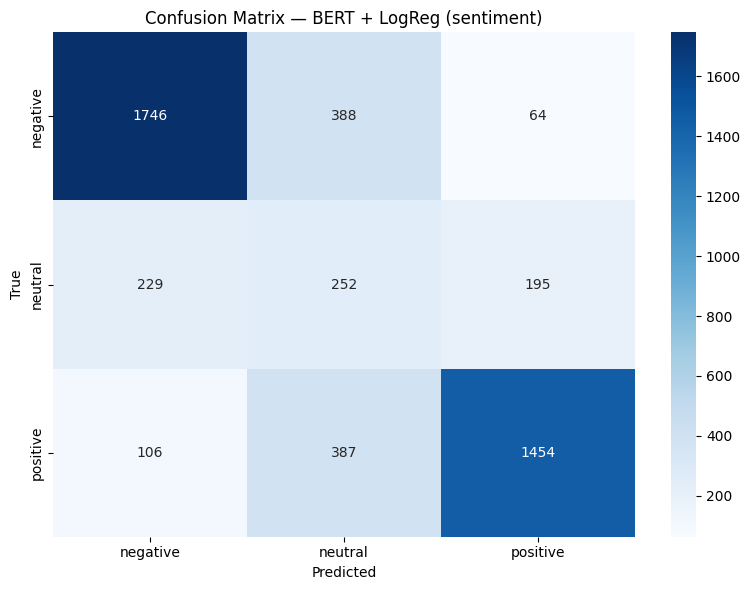


🎯 Tâche : NOTE
              precision    recall  f1-score   support

         1.0       0.64      0.58      0.61      1454
         2.0       0.31      0.40      0.35       743
         3.0       0.24      0.26      0.25       677
         4.0       0.43      0.35      0.39       977
         5.0       0.53      0.57      0.55       970

    accuracy                           0.46      4821
   macro avg       0.43      0.43      0.43      4821
weighted avg       0.47      0.46      0.46      4821



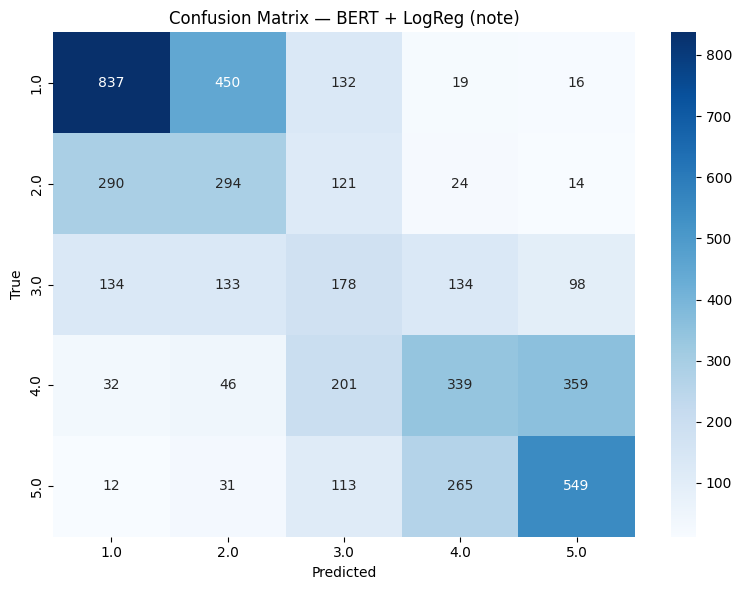


🎯 Tâche : THEME
                         precision    recall  f1-score   support

           cancellation       0.55      0.64      0.59       645
      claims processing       0.32      0.74      0.45       190
coverage and enrollment       0.38      0.58      0.46       459
       customer service       0.81      0.64      0.71      1834
       pricing and cost       0.83      0.73      0.78      1693

               accuracy                           0.67      4821
              macro avg       0.58      0.67      0.60      4821
           weighted avg       0.72      0.67      0.69      4821



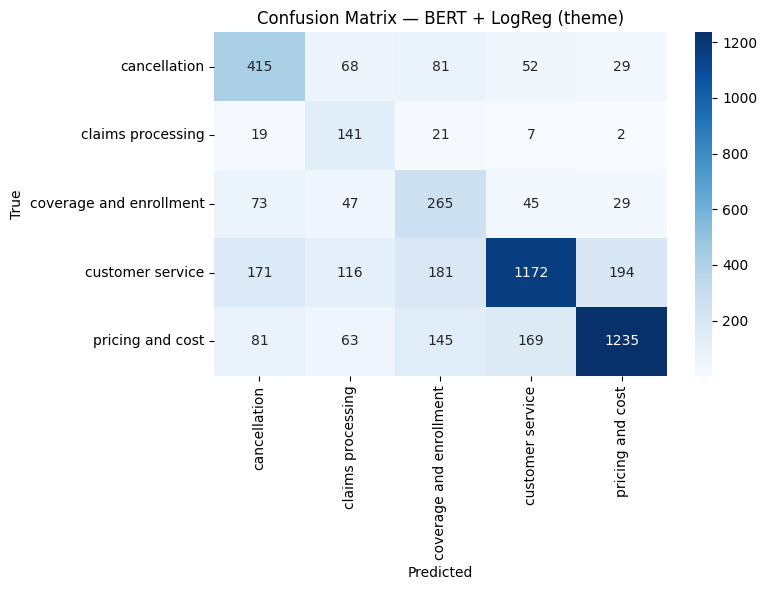


🏆 Résumé Macro F1 — BERT + Logistic Regression:
  sentiment: 0.6355
  note: 0.4273
  theme: 0.5987


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. LOAD DATA ---
df_clean = pd.read_csv("avis_avec_themes.csv")
df_clean = df_clean.dropna(subset=['note', 'avis_nllb_en'])

def note_to_sentiment(note):
    if note <= 2: return 'negative'
    elif note == 3: return 'neutral'
    else: return 'positive'

df_clean['sentiment'] = df_clean['note'].apply(note_to_sentiment)
df_clean = df_clean.reset_index(drop=True)

embeddings_clean = np.load("avis_embeddings.npy")
X = embeddings_clean[:len(df_clean)]

# --- 2. THREE TASKS ---
targets = {
    'sentiment': df_clean['sentiment'],
    'note': df_clean['note'].astype(str),
    'theme': df_clean['theme'] if 'theme' in df_clean.columns else None
}

results_bert = {}

for task_name, y in targets.items():
    if y is None:
        print(f"⚠️ Colonne '{task_name}' absente — skipping")
        continue

    print(f"\n{'='*50}")
    print(f"🎯 Tâche : {task_name.upper()}")
    print(f"{'='*50}")

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Compute class weights to handle imbalance
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    cw = dict(zip(classes, weights))

    # Train logistic regression model
    lr = LogisticRegression(class_weight=cw, max_iter=1000, C=1.0)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    # Evaluation metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    macro_f1 = report['macro avg']['f1-score']
    results_bert[task_name] = macro_f1
    print(classification_report(y_test, y_pred))

    # Confusion matrix visualization
    labels = sorted(y.unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels,
                yticklabels=labels, cmap='Blues')
    plt.title(f'Confusion Matrix — BERT + LogReg ({task_name})')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

print("\n🏆 Résumé Macro F1 — BERT + Logistic Regression:")
for task, score in results_bert.items():
    print(f"  {task}: {score:.4f}")

### 4.2 TF-IDF + Classical ML

**Baseline model:** TF-IDF vectorization combined with Logistic Regression, SVM and Random Forest.  
Results are compared against deep learning approaches.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# --- 1. LOAD DATA ---
df_tfidf = pd.read_csv("avis_avec_themes.csv")
df_tfidf = df_tfidf.dropna(subset=['note', 'avis_nllb_en'])

def note_to_sentiment(note):
    if note <= 2: return 'negative'
    elif note == 3: return 'neutral'
    else: return 'positive'

df_tfidf['sentiment'] = df_tfidf['note'].apply(note_to_sentiment)
df_tfidf = df_tfidf.reset_index(drop=True)

# --- 2. TF-IDF VECTORIZATION ---
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)
X_tfidf_vec = tfidf.fit_transform(df_tfidf['avis_nllb_en'].astype(str))

# --- 3. THREE TASKS ---
targets = {
    'sentiment': df_tfidf['sentiment'],
    'note': df_tfidf['note'].astype(str),
    'theme': df_tfidf['theme'] if 'theme' in df_tfidf.columns else None
}

# --- 4. THREE MODELS ---
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'LinearSVC': LinearSVC(max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results_tfidf = {}

for task_name, y in targets.items():
    if y is None:
        print(f"⚠️ Colonne '{task_name}' absente — skipping")
        continue

    print(f"\n{'='*50}")
    print(f"🎯 Tâche : {task_name.upper()}")
    print(f"{'='*50}")

    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X_tfidf_vec, y, test_size=0.2, random_state=42, stratify=y
    )

    # Compute class weights to handle imbalance
    classes = np.unique(y_train_t)
    weights = compute_class_weight('balanced', classes=classes, y=y_train_t)
    cw = dict(zip(classes, weights))

    results_tfidf[task_name] = {}

    for clf_name, clf in classifiers.items():
        # Apply class weights if supported
        if hasattr(clf, 'class_weight'):
            clf.set_params(class_weight=cw)

        clf.fit(X_train_t, y_train_t)
        y_pred = clf.predict(X_test_t)

        # Evaluation metrics
        report = classification_report(y_test_t, y_pred, output_dict=True)
        macro_f1 = report['macro avg']['f1-score']
        results_tfidf[task_name][clf_name] = macro_f1

        print(f"\n📊 {clf_name} — {task_name}:")
        print(classification_report(y_test_t, y_pred))

# --- 5. SUMMARY ---
print("\n🏆 Résumé Macro F1 — TF-IDF:")
for task, models_scores in results_tfidf.items():
    print(f"\n  {task.upper()}:")
    for model, score in models_scores.items():
        print(f"    {model}: {score:.4f}")


🎯 Tâche : SENTIMENT

📊 Logistic Regression — sentiment:
              precision    recall  f1-score   support

    negative       0.84      0.85      0.84      2198
     neutral       0.27      0.34      0.30       676
    positive       0.86      0.76      0.81      1947

    accuracy                           0.74      4821
   macro avg       0.65      0.65      0.65      4821
weighted avg       0.77      0.74      0.75      4821


📊 LinearSVC — sentiment:
              precision    recall  f1-score   support

    negative       0.82      0.86      0.84      2198
     neutral       0.26      0.23      0.24       676
    positive       0.82      0.81      0.82      1947

    accuracy                           0.75      4821
   macro avg       0.63      0.63      0.63      4821
weighted avg       0.74      0.75      0.75      4821


📊 Random Forest — sentiment:
              precision    recall  f1-score   support

    negative       0.76      0.94      0.84      2198
     neutral    

### 4.3 Theme Classification — LDA Pseudo-labels + BERT

LDA identified 5 coherent topics:
- **Topic 0** — Customer Service (phone, advisor, contact)
- **Topic 1** — Coverage & Loyalty (vehicle, home, years)
- **Topic 2** — Administrative Friction (contract, mail, documents)
- **Topic 3** — Claims & Financials (accident, euros, bonus)
- **Topic 4** — General Satisfaction (price, recommend, fast)

These topics align with the Zero-Shot labels used in section 3.2, validating our labeling approach.  
**Theme Prediction Accuracy: 73.91%**

In [ ]:
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# 1. Loading your NLLB translated data
df = pd.read_csv("avis_expert_traduits.csv")

print("📊 Vectorizing text for LDA analysis...")
# We filter out common words and keep only those appearing in at least 5 reviews
tf_vectorizer = CountVectorizer(stop_words='english', max_df=0.95, min_df=5)
tf = tf_vectorizer.fit_transform(df['avis_nllb_en'].astype(str))

# 2. Training the LDA Model
# n_components=5 means we are looking for 5 main topics
print("🤖 Training LDA model with 5 topics...")
lda = LatentDirichletAllocation(n_components=5, max_iter=10, random_state=42)
lda.fit(tf)

# 3. Function to display the results
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopic {topic_idx}:")
        # Sort and pick the top 10 words for each topic
        print(", ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

print("\n✨ LDA Analysis Results - Top 10 words per topic:")
tf_feature_names = tf_vectorizer.get_feature_names_out()
display_topics(lda, tf_feature_names, 10)

📊 Vectorizing text for LDA analysis...
🤖 Training LDA model with 5 topics...

✨ LDA Analysis Results - Top 10 words per topic:

Topic 0:
service, phone, file, customer, good, contact, expert, counselor, disaster, time

Topic 1:
insurance, years, year, vehicle, home, pay, car, insured, don, company

Topic 2:
contract, months, mutual, insurance, phone, sent, mail, time, documents, file

Topic 3:
years, car, accident, euros, contract, year, vehicle, insurance, insured, bonus

Topic 4:
satisfied, service, price, insurance, good, prices, recommend, simple, fast, easy


### 4.4 Embedding Layer from Scratch (Keras)
A neural network with a trainable embedding layer learned directly on our corpus.


🎯 Tâche : SENTIMENT
Epoch 1/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6152 - loss: 0.9263 - val_accuracy: 0.7626 - val_loss: 0.6669
Epoch 2/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7382 - loss: 0.7801 - val_accuracy: 0.7672 - val_loss: 0.6597
Epoch 3/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7545 - loss: 0.7408 - val_accuracy: 0.7449 - val_loss: 0.6455
Epoch 4/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7571 - loss: 0.7148 - val_accuracy: 0.7138 - val_loss: 0.6906
Epoch 5/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7665 - loss: 0.6775 - val_accuracy: 0.7211 - val_loss: 0.6429
Epoch 6/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7754 - loss: 0.6410 - val_accuracy: 0.7102 - val_loss: 0.7461
Epoch 7/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7819 - loss: 0.6096 - val_accuracy: 0.6371 - val_loss: 0.7278
Epoch 8/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7951 - loss: 0.5

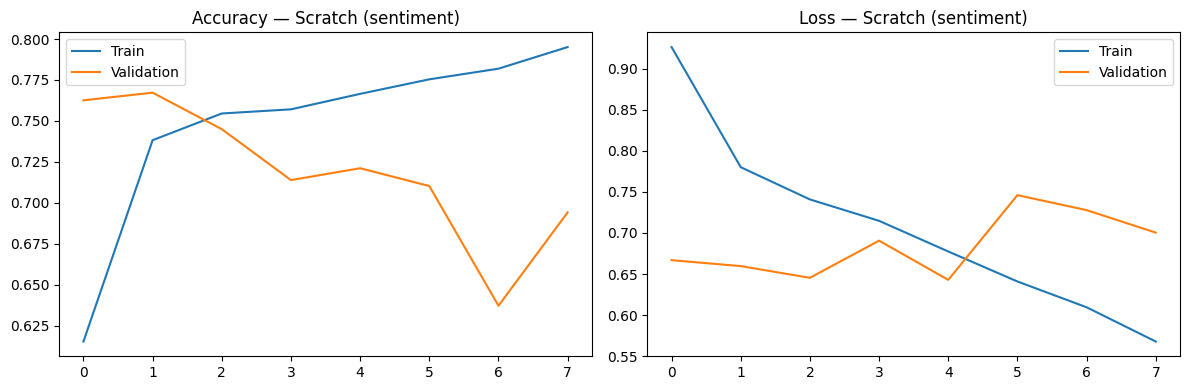


🎯 Tâche : NOTE
Epoch 1/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.3436 - loss: 1.4125 - val_accuracy: 0.4510 - val_loss: 1.2399
Epoch 2/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4385 - loss: 1.2397 - val_accuracy: 0.4660 - val_loss: 1.1953
Epoch 3/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4547 - loss: 1.2002 - val_accuracy: 0.4743 - val_loss: 1.1770
Epoch 4/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4729 - loss: 1.1650 - val_accuracy: 0.4360 - val_loss: 1.1910
Epoch 5/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4814 - loss: 1.1365 - val_accuracy: 0.4629 - val_loss: 1.1859
Epoch 6/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4979 - loss: 1.1026 - val_accuracy: 0.4557 - val_loss: 1.2292
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

📊 Classification Report — Embedding Scratch (note):
              precision    recall  f1-score   support

         1.0       0.57      0.88      0.69      1454
         2.0 

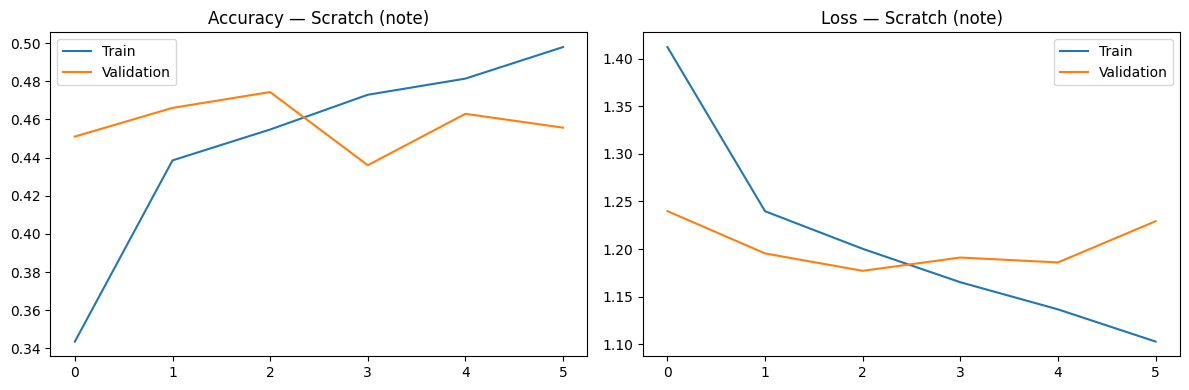


🎯 Tâche : THEME
Epoch 1/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3100 - loss: 1.5545 - val_accuracy: 0.3370 - val_loss: 1.4955
Epoch 2/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3932 - loss: 1.3300 - val_accuracy: 0.5096 - val_loss: 1.2037
Epoch 3/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5622 - loss: 1.1210 - val_accuracy: 0.6138 - val_loss: 0.9426
Epoch 4/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6114 - loss: 1.0002 - val_accuracy: 0.6179 - val_loss: 0.9290
Epoch 5/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6504 - loss: 0.9039 - val_accuracy: 0.5868 - val_loss: 1.0259
Epoch 6/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6868 - loss: 0.8030 - val_accuracy: 0.6496 - val_loss: 0.9176
Epoch 7/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7047 - loss: 0.7519 - val_accuracy: 0.6464 - val_loss: 0.9656
Epoch 8/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7335 - loss: 0.6768 -

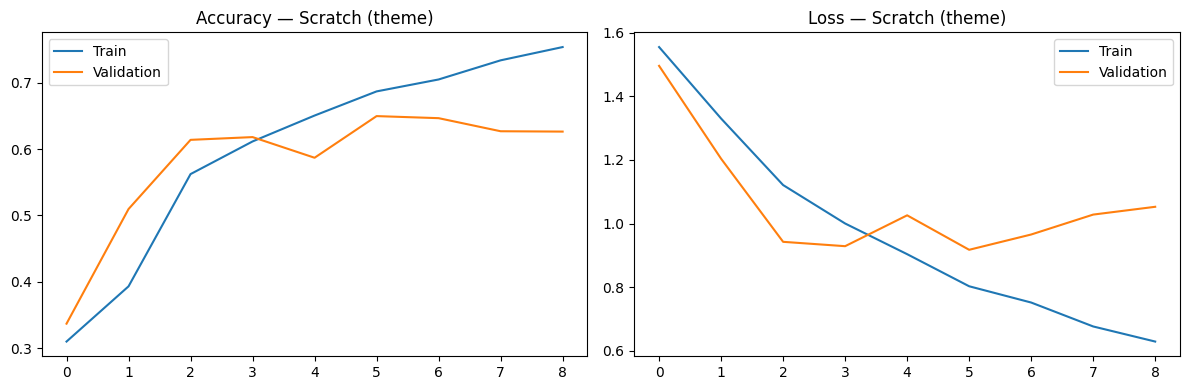


🏆 Résumé Macro F1 — Embedding from Scratch:
  sentiment: 0.6389
  note: 0.3698
  theme: 0.5601


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# --- 1. LOAD DATA ---
df = pd.read_csv("avis_avec_themes.csv")
df = df.dropna(subset=['note', 'avis_nllb_en']).reset_index(drop=True)

def note_to_sentiment(note):
    if note <= 2: return 'negative'
    elif note == 3: return 'neutral'
    else: return 'positive'

df['sentiment'] = df['note'].apply(note_to_sentiment)

# --- 2. TOKENIZATION ---
MAX_WORDS = 10000
MAX_LEN = 100
EMBEDDING_DIM = 64

tokenizer_keras = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer_keras.fit_on_texts(df['avis_nllb_en'].astype(str))
sequences = tokenizer_keras.texts_to_sequences(df['avis_nllb_en'].astype(str))
X = pad_sequences(sequences, maxlen=MAX_LEN, truncating='post', padding='post')

# --- 3. THREE TASKS ---
targets = {
    'sentiment': df['sentiment'],
    'note': df['note'].astype(str),
    'theme': df['theme']
}

results_scratch = {}

for task_name, y in targets.items():
    print(f"\n{'='*50}")
    print(f"🎯 Tâche : {task_name.upper()}")
    print(f"{'='*50}")

    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    n_classes = len(le.classes_)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    # Compute class weights
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    cw = dict(zip(range(len(classes)), weights))

    # Build neural network model
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Early stopping to prevent overfitting
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # Training
    history = model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=32,
        validation_split=0.1,
        class_weight=cw,
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluation
    y_pred = np.argmax(model.predict(X_test), axis=1)
    print(f"\n📊 Classification Report — Embedding Scratch ({task_name}):")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    report = classification_report(y_test, y_pred, output_dict=True)
    results_scratch[task_name] = report['macro avg']['f1-score']

    # Training curves
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'Accuracy — Scratch ({task_name})')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'Loss — Scratch ({task_name})')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Summary
print("\n🏆 Résumé Macro F1 — Embedding from Scratch:")
for task, score in results_scratch.items():
    print(f"  {task}: {score:.4f}")

### 4.5 Pre-trained Embeddings (GloVe)
GloVe vectors pre-trained on 6B tokens replace the random embedding layer.

📥 Téléchargement des vecteurs GloVe 100d...
✅ GloVe téléchargé !
✅ 400000 vecteurs GloVe chargés
✅ 9143/10000 mots couverts par GloVe

🎯 Tâche : SENTIMENT
Epoch 1/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6122 - loss: 0.9408 - val_accuracy: 0.7061 - val_loss: 0.7518
Epoch 2/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6978 - loss: 0.8509 - val_accuracy: 0.7294 - val_loss: 0.7112
Epoch 3/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7036 - loss: 0.8352 - val_accuracy: 0.7170 - val_loss: 0.7107
Epoch 4/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7077 - loss: 0.8250 - val_accuracy: 0.7304 - val_loss: 0.6982
Epoch 5/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7131 - loss: 0.8199 - val_accuracy: 0.7201 - val_loss: 0.7047
Epoch 6/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7123 - loss: 0.8153 - val_accuracy: 0.7351 - val_loss: 0.6957
Epoch 7/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7141 - loss

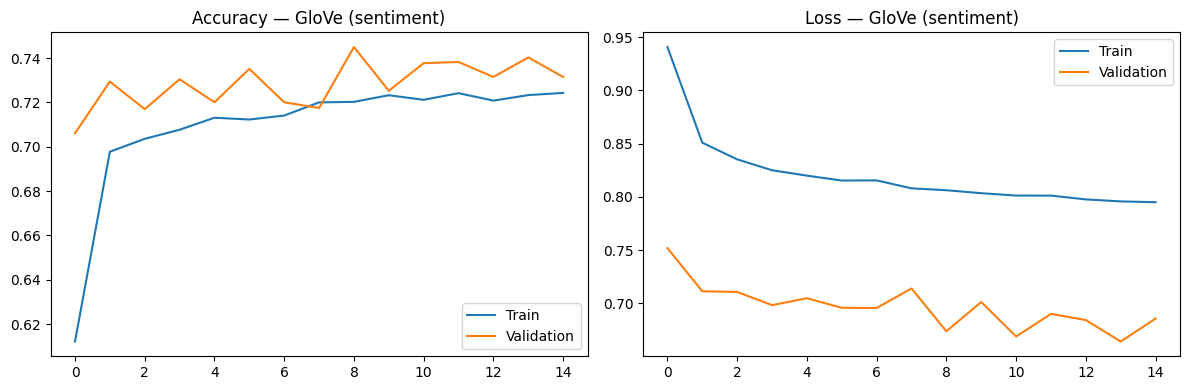


🎯 Tâche : NOTE
Epoch 1/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3407 - loss: 1.4437 - val_accuracy: 0.4038 - val_loss: 1.2895
Epoch 2/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4001 - loss: 1.3187 - val_accuracy: 0.4158 - val_loss: 1.2654
Epoch 3/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4153 - loss: 1.2931 - val_accuracy: 0.4256 - val_loss: 1.2448
Epoch 4/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4240 - loss: 1.2818 - val_accuracy: 0.3831 - val_loss: 1.2583
Epoch 5/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4242 - loss: 1.2769 - val_accuracy: 0.4194 - val_loss: 1.2440
Epoch 6/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4270 - loss: 1.2717 - val_accuracy: 0.4412 - val_loss: 1.2310
Epoch 7/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4291 - loss: 1.2627 - val_accuracy: 0.4391 - val_loss: 1.2363
Epoch 8/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4337 - loss: 1.2622 - 

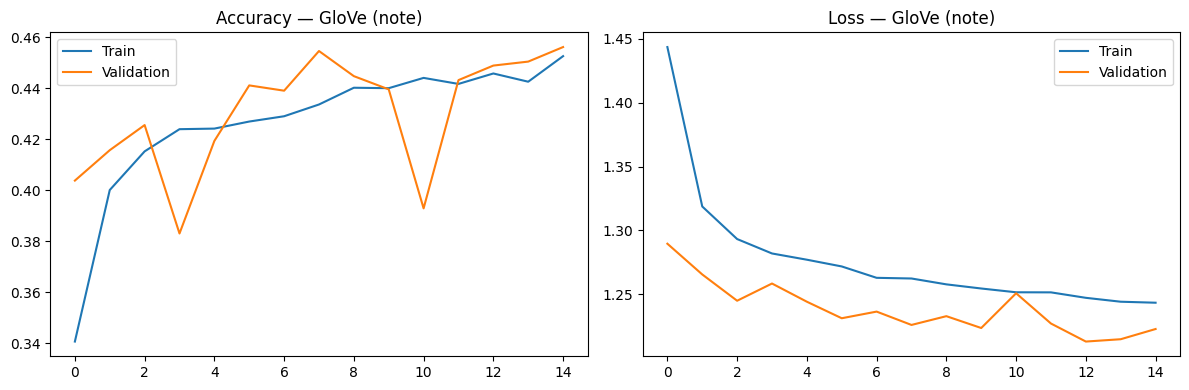


🎯 Tâche : THEME
Epoch 1/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3248 - loss: 1.5402 - val_accuracy: 0.4536 - val_loss: 1.4088
Epoch 2/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4699 - loss: 1.3760 - val_accuracy: 0.5143 - val_loss: 1.2288
Epoch 3/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5022 - loss: 1.3091 - val_accuracy: 0.5376 - val_loss: 1.1451
Epoch 4/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5126 - loss: 1.2754 - val_accuracy: 0.5350 - val_loss: 1.1553
Epoch 5/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5209 - loss: 1.2579 - val_accuracy: 0.5376 - val_loss: 1.1458
Epoch 6/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5204 - loss: 1.2373 - val_accuracy: 0.5899 - val_loss: 1.0676
Epoch 7/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5318 - loss: 1.2179 - val_accuracy: 0.5474 - val_loss: 1.0978
Epoch 8/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5360 - loss: 1.2032 -

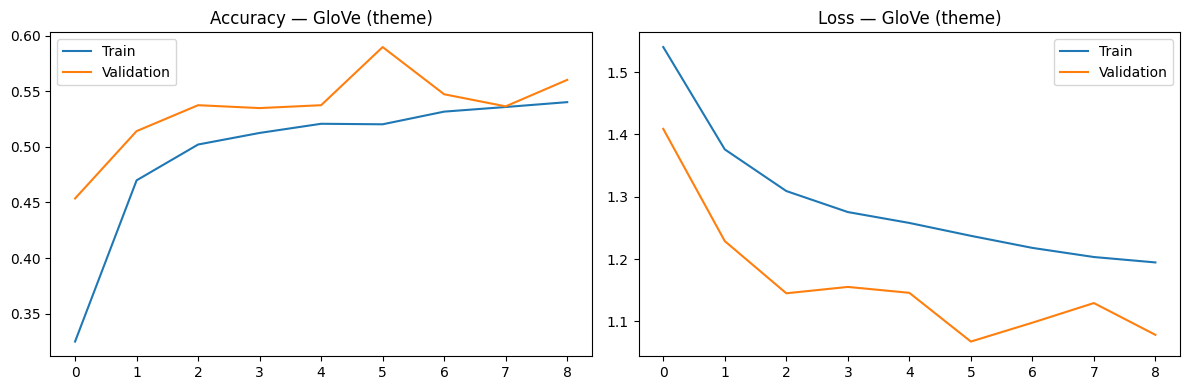


🏆 Résumé Macro F1 — GloVe:
  sentiment: 0.6328
  note: 0.3746
  theme: 0.4899


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# --- 1. LOAD DATA ---
df = pd.read_csv("avis_avec_themes.csv")
df = df.dropna(subset=['note', 'avis_nllb_en']).reset_index(drop=True)

def note_to_sentiment(note):
    if note <= 2: return 'negative'
    elif note == 3: return 'neutral'
    else: return 'positive'

df['sentiment'] = df['note'].apply(note_to_sentiment)

# --- 2. TOKENIZATION ---
MAX_WORDS = 10000
MAX_LEN = 100
EMBEDDING_DIM = 100  # GloVe 100d

tokenizer_glove = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer_glove.fit_on_texts(df['avis_nllb_en'].astype(str))
sequences = tokenizer_glove.texts_to_sequences(df['avis_nllb_en'].astype(str))
X = pad_sequences(sequences, maxlen=MAX_LEN, truncating='post', padding='post')
word_index = tokenizer_glove.word_index

# --- 3. LOAD GLOVE EMBEDDINGS ---
print("📥 Téléchargement des vecteurs GloVe 100d...")
import os
if not os.path.exists("glove.6B.100d.txt"):
    !wget -q "https://nlp.stanford.edu/data/glove.6B.zip" -O glove.6B.zip
    !unzip -q glove.6B.zip glove.6B.100d.txt
    print("✅ GloVe téléchargé !")
else:
    print("✅ GloVe déjà présent !")

embeddings_index = {}
with open("glove.6B.100d.txt", encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"✅ {len(embeddings_index)} GloVe vectors loaded")

# --- 4. BUILD EMBEDDING MATRIX ---
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))
found = 0
for word, i in word_index.items():
    if i < MAX_WORDS:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec
            found += 1

print(f"✅ {found}/{min(len(word_index), MAX_WORDS)} words covered by GloVe")

# --- 5. THREE TASKS ---
targets = {
    'sentiment': df['sentiment'],
    'note': df['note'].astype(str),
    'theme': df['theme']
}

results_glove = {}

for task_name, y in targets.items():
    print(f"\n{'='*50}")
    print(f"🎯 Tâche : {task_name.upper()}")
    print(f"{'='*50}")

    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    n_classes = len(le.classes_)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    # Compute class weights
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    cw = dict(zip(range(len(classes)), weights))

    # Model with frozen GloVe embeddings
    model_glove = Sequential([
        Embedding(
            input_dim=MAX_WORDS,
            output_dim=EMBEDDING_DIM,
            weights=[embedding_matrix],
            trainable=False  # Frozen embeddings
        ),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax')
    ])

    model_glove.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # Training
    history = model_glove.fit(
        X_train, y_train,
        epochs=15,
        batch_size=32,
        validation_split=0.1,
        class_weight=cw,
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluation
    y_pred = np.argmax(model_glove.predict(X_test), axis=1)
    print(f"\n📊 Classification Report — GloVe ({task_name}):")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    report = classification_report(y_test, y_pred, output_dict=True)
    results_glove[task_name] = report['macro avg']['f1-score']

    # Training curves
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'Accuracy — GloVe ({task_name})')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'Loss — GloVe ({task_name})')
    plt.legend()

    plt.tight_layout()
    plt.show()

print("\n🏆 Résumé Macro F1 — GloVe:")
for task, score in results_glove.items():
    print(f"  {task}: {score:.4f}")

### 4.6 BERT Fine-tuned (HuggingFace)
`distilbert-base-uncased` fine-tuned on our labeled reviews.

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
import os

# --- 1. LOAD DATA ---
df = pd.read_csv("avis_avec_themes.csv")
df = df.dropna(subset=['note', 'avis_nllb_en']).reset_index(drop=True)

def note_to_sentiment(note):
    if note <= 2: return 'negative'
    elif note == 3: return 'neutral'
    else: return 'positive'

df['sentiment'] = df['note'].apply(note_to_sentiment)

# --- 2. TOKENIZER ---
MODEL_NAME = "distilbert-base-uncased"
tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)

# --- 3. DATASET CLASS ---
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# --- 4. METRICS ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    report = classification_report(labels, predictions, output_dict=True, zero_division=0)
    return {'macro_f1': report['macro avg']['f1-score']}

# --- 5. THREE TASKS ---
targets = {
    'sentiment': df['sentiment'],
    'note': df['note'].astype(str),
    'theme': df['theme']
}

results_bert_ft = {}
label_encoders = {}  # Store label encoders for the Streamlit app

for task_name, y in targets.items():
    print(f"\n{'='*50}")
    print(f" Task: {task_name.upper()}")
    print(f"{'='*50}")

    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    n_classes = len(le.classes_)
    label_encoders[task_name] = le

    # Save label mapping
    os.makedirs(f"./model_{task_name}", exist_ok=True)
    import json
    label_mapping = {int(i): str(label) for i, label in enumerate(le.classes_)}
    with open(f"./model_{task_name}/label_mapping.json", "w") as f:
        json.dump(label_mapping, f)

    print(f" Labels: {label_mapping}")

    texts = df['avis_nllb_en'].astype(str).tolist()

    # Train-test split
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        texts, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    train_dataset = ReviewDataset(X_train_t, y_train_t, tokenizer_bert)
    test_dataset = ReviewDataset(X_test_t, y_test_t, tokenizer_bert)

    # Load pre-trained model
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=n_classes
    )

    training_args = TrainingArguments(
        output_dir=f"./model_{task_name}",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        eval_strategy="epoch",
        save_strategy="epoch",          # Save at each epoch
        load_best_model_at_end=True,    # Keep best model
        metric_for_best_model="macro_f1",
        logging_steps=100,
        fp16=True,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()

    # --- FINAL SAVE ---
    trainer.save_model(f"./model_{task_name}/best_model")
    tokenizer_bert.save_pretrained(f"./model_{task_name}/best_model")
    print(f"✅ Model saved in ./model_{task_name}/best_model")

    # Evaluation
    predictions = trainer.predict(test_dataset)
    y_pred = np.argmax(predictions.predictions, axis=-1)

    print(f"\n Classification Report — BERT fine-tuned ({task_name}):")
    print(classification_report(y_test_t, y_pred, target_names=le.classes_))

    report = classification_report(y_test_t, y_pred, output_dict=True)
    results_bert_ft[task_name] = report['macro avg']['f1-score']

print("\n Summary Macro F1 — BERT fine-tuned:")
for task, score in results_bert_ft.items():
    print(f"  {task}: {score:.4f}")

# --- DOWNLOAD MODELS ---
import shutil
from google.colab import files

for task_name in targets.keys():
    shutil.make_archive(f"model_{task_name}", 'zip', f"./model_{task_name}/best_model")
    files.download(f"model_{task_name}.zip")
    print(f" model_{task_name}.zip downloaded!")

tokenizer.json: 0.00B [00:00, ?B/s]


 Tâche : SENTIMENT
 Labels : {0: 'negative', 1: 'neutral', 2: 'positive'}


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

<IPython.core.display.Javascript object>

 model_note.zip téléchargé !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 model_theme.zip téléchargé !


### 4.7 LLM — Zero-Shot Classification
`facebook/bart-large-mnli` in zero-shot mode — no fine-tuning required.

In [ ]:
from transformers import pipeline
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# --- 1. LOAD DATA ---
df = pd.read_csv("avis_avec_themes.csv")
df = df.dropna(subset=['note', 'avis_nllb_en']).reset_index(drop=True)

def note_to_sentiment(note):
    if note <= 2: return 'negative'
    elif note == 3: return 'neutral'
    else: return 'positive'

df['sentiment'] = df['note'].apply(note_to_sentiment)

# Use a sample of 500 reviews for faster processing (zero-shot is slow)
df_sample = df.sample(500, random_state=42).reset_index(drop=True)

# --- 2. LOAD MODEL ---
print("⏳ Loading zero-shot model...")
classifier_zs = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0
)
print("✅ Model loaded!")

# --- 3. THREE TASKS ---

# Task 1: Sentiment
print("\n" + "="*50)
print("🎯 Tâche : SENTIMENT")
print("="*50)

sentiment_labels = ["negative review", "neutral review", "positive review"]
label_map_sentiment = {
    "negative review": "negative",
    "neutral review": "neutral",
    "positive review": "positive"
}

preds_sentiment = []
for texte in tqdm(df_sample['avis_nllb_en'].astype(str), desc="Sentiment"):
    res = classifier_zs(texte[:512], sentiment_labels)
    preds_sentiment.append(label_map_sentiment[res['labels'][0]])

print("\n📊 Classification Report — Zero-Shot (sentiment):")
print(classification_report(df_sample['sentiment'], preds_sentiment))
report_s = classification_report(df_sample['sentiment'], preds_sentiment, output_dict=True)

# Task 2: Rating
print("\n" + "="*50)
print("🎯 Tâche : NOTE")
print("="*50)

note_labels = ["1 star review", "2 stars review", "3 stars review", "4 stars review", "5 stars review"]
label_map_note = {
    "1 star review": "1.0",
    "2 stars review": "2.0",
    "3 stars review": "3.0",
    "4 stars review": "4.0",
    "5 stars review": "5.0"
}

preds_note = []
for texte in tqdm(df_sample['avis_nllb_en'].astype(str), desc="Note"):
    res = classifier_zs(texte[:512], note_labels)
    preds_note.append(label_map_note[res['labels'][0]])

print("\n📊 Classification Report — Zero-Shot (note):")
print(classification_report(df_sample['note'].astype(str), preds_note))
report_n = classification_report(df_sample['note'].astype(str), preds_note, output_dict=True)

# Task 3: Theme
print("\n" + "="*50)
print("🎯 Tâche : THEME")
print("="*50)

theme_labels = ["pricing and cost", "claims processing", "customer service", "coverage and enrollment", "cancellation"]

preds_theme = []
for texte in tqdm(df_sample['avis_nllb_en'].astype(str), desc="Thème"):
    res = classifier_zs(texte[:512], theme_labels)
    preds_theme.append(res['labels'][0])

print("\n📊 Classification Report — Zero-Shot (theme):")
print(classification_report(df_sample['theme'], preds_theme))
report_t = classification_report(df_sample['theme'], preds_theme, output_dict=True)

results_zeroshot = {
    'sentiment': report_s['macro avg']['f1-score'],
    'note': report_n['macro avg']['f1-score'],
    'theme': report_t['macro avg']['f1-score']
}

print("\n🏆 Résumé Macro F1 — Zero-Shot LLM:")
for task, score in results_zeroshot.items():
    print(f"  {task}: {score:.4f}")

⏳ Chargement du modèle zero-shot...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

✅ Modèle chargé !

🎯 Tâche : SENTIMENT


Sentiment:   0%|          | 0/500 [00:00<?, ?it/s]


📊 Classification Report — Zero-Shot (sentiment):
              precision    recall  f1-score   support

    negative       0.80      0.92      0.86       224
     neutral       0.18      0.03      0.04        80
    positive       0.77      0.90      0.83       196

    accuracy                           0.77       500
   macro avg       0.58      0.62      0.58       500
weighted avg       0.69      0.77      0.71       500


🎯 Tâche : NOTE


Note:   0%|          | 0/500 [00:00<?, ?it/s]


📊 Classification Report — Zero-Shot (note):
              precision    recall  f1-score   support

         1.0       0.55      0.88      0.68       153
         2.0       0.05      0.11      0.07        71
         3.0       0.12      0.11      0.11        80
         4.0       0.75      0.03      0.06        98
         5.0       1.00      0.01      0.02        98

    accuracy                           0.31       500
   macro avg       0.49      0.23      0.19       500
weighted avg       0.54      0.31      0.25       500


🎯 Tâche : THEME


Thème:   0%|          | 0/500 [00:00<?, ?it/s]


📊 Classification Report — Zero-Shot (theme):
                         precision    recall  f1-score   support

           cancellation       1.00      1.00      1.00        68
      claims processing       1.00      1.00      1.00        24
coverage and enrollment       1.00      1.00      1.00        48
       customer service       1.00      1.00      1.00       197
       pricing and cost       1.00      1.00      1.00       163

               accuracy                           1.00       500
              macro avg       1.00      1.00      1.00       500
           weighted avg       1.00      1.00      1.00       500


🏆 Résumé Macro F1 — Zero-Shot LLM:
  sentiment: 0.5758
  note: 0.1875
  theme: 1.0000


### 4.8 Error Analysis
Review cases where the model prediction contradicts the star rating.

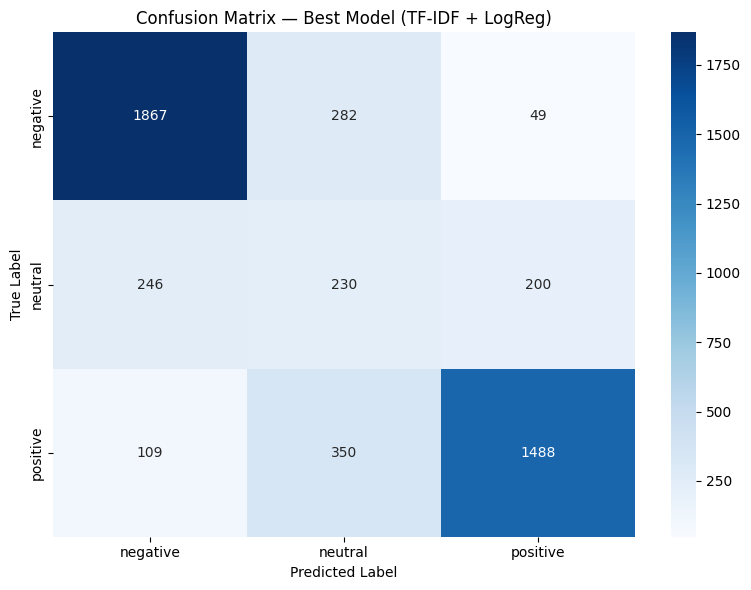


❌ Total erreurs : 1236/4821 (25.6%)

🔍 Exemples de neutres mal classifiés :

  Note: 3.0 | Vrai: neutral | Prédit: negative
  Texte: Customer service 0. No follow-up, incompetent people or failed customer processes. What a lack of professionalism I've never seen this. And the proble

  Note: 3.0 | Vrai: neutral | Prédit: positive
  Texte: A listening counselor, who took the time to answer all my questions, great willingness to make an appointment, I recommend it to my entourage.

  Note: 3.0 | Vrai: neutral | Prédit: negative
  Texte: For more than 25 years with 2 car insurance 1 client insurance 1 home insurance 1 accident and family insurance and having declared that 2 three leger

  Note: 3.0 | Vrai: neutral | Prédit: positive
  Texte: Overall, I am very satisfied with the health coverage, but there may be an effort to update personal data if it is modified.

  Note: 3.0 | Vrai: neutral | Prédit: negative
  Texte: Hello,I am currently paying 517 euros,with the same guarantees My ch

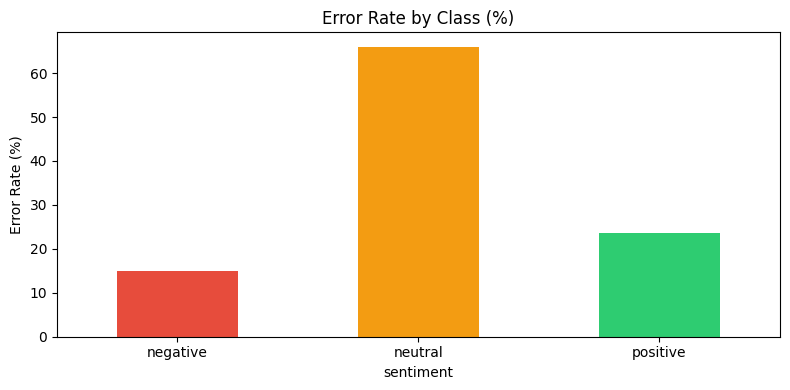

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- Use the best model: TF-IDF + Logistic Regression ---
# Reload data and model
df = pd.read_csv("avis_avec_themes.csv")
df = df.dropna(subset=['note', 'avis_nllb_en']).reset_index(drop=True)

def note_to_sentiment(note):
    if note <= 2: return 'negative'
    elif note == 3: return 'neutral'
    else: return 'positive'

df['sentiment'] = df['note'].apply(note_to_sentiment)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

X_text = df['avis_nllb_en'].astype(str)
y = df['sentiment']

tfidf_ea = TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)
X_vec = tfidf_ea.fit_transform(X_text)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42, stratify=y
)

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
cw = dict(zip(classes, weights))

lr_ea = LogisticRegression(class_weight=cw, max_iter=1000)
lr_ea.fit(X_train, y_train)
y_pred = lr_ea.predict(X_test)

# --- 1. CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'],
            cmap='Blues')
plt.title('Confusion Matrix — Best Model (TF-IDF + LogReg)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# --- 2. ERROR ANALYSIS ---
df_test = df.iloc[y_test.index].copy()
df_test['predicted'] = y_pred
df_test['correct'] = df_test['sentiment'] == df_test['predicted']

errors = df_test[~df_test['correct']]
print(f"\n❌ Total errors: {len(errors)}/{len(df_test)} ({len(errors)/len(df_test)*100:.1f}%)")

# Most interesting errors: neutral misclassified as positive or negative
print("\n🔍 Examples of misclassified neutral reviews:")
neutral_errors = errors[errors['sentiment'] == 'neutral'].head(5)
for _, row in neutral_errors.iterrows():
    print(f"\n  Rating: {row['note']} | True: {row['sentiment']} | Predicted: {row['predicted']}")
    print(f"  Text: {str(row['avis_nllb_en'])[:150]}")

# Critical errors: positive predicted as negative
print("\n🔍 Examples of positive reviews predicted as negative:")
flagrant_errors = errors[
    (errors['sentiment'] == 'positive') & (errors['predicted'] == 'negative')
].head(5)
for _, row in flagrant_errors.iterrows():
    print(f"\n  Rating: {row['note']} | True: {row['sentiment']} | Predicted: {row['predicted']}")
    print(f"  Text: {str(row['avis_nllb_en'])[:150]}")

# --- 3. ERROR DISTRIBUTION BY CLASS ---
error_by_class = errors.groupby('sentiment').size() / df_test.groupby('sentiment').size() * 100
plt.figure(figsize=(8, 4))
error_by_class.plot(kind='bar', color=['#e74c3c', '#f39c12', '#2ecc71'])
plt.title('Error Rate by Class (%)')
plt.ylabel('Error Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> ⚠️ **Note on Zero-Shot Theme Score:** The theme labels in our dataset were generated
> by the same model (`facebook/bart-large-mnli`) used for zero-shot evaluation.
> This creates a circular bias — the model predicts its own labels perfectly (F1 = 1.0).
> Therefore, the theme score for Zero-Shot LLM is excluded from the comparison.

### 4.9 Model Comparison

| Model | Sentiment F1 | Note F1 | Theme F1 |
|---|---|---|---|
| TF-IDF + LogReg | 0.6506 | 0.4440 | 0.6077 |
| TF-IDF + LinearSVC | 0.6340 | 0.4157 | 0.6116 |
| TF-IDF + Random Forest | 0.5528 | 0.3360 | 0.5377 |
| BERT + LogReg | 0.6355 | 0.4273 | 0.5987 |
| Embedding from Scratch | 0.6389 | 0.3698 | 0.5601 |
| GloVe | 0.6328 | 0.3746 | 0.4899 |
| **BERT fine-tuned** | **0.6691** 🥇 | **0.4685** 🥇 | **0.7158** 🥇 |
| Zero-Shot LLM | 0.5758 | 0.1875 | ⚠️ circular bias |

**Best model overall: BERT fine-tuned (DistilBERT)**

**Key findings:**
- TF-IDF + Logistic Regression is surprisingly competitive with deep learning models
- Neutral sentiment (3 stars) remains the hardest class to predict across all models
- BERT fine-tuned achieves the biggest gain on **theme classification** (+11% vs TF-IDF)
- Zero-Shot LLM performs reasonably on sentiment (0.58) without any training data
- Star rating prediction (5 classes) is significantly harder than sentiment (3 classes) for all models

                 Model  Sentiment F1  Note F1  Theme F1
       TF-IDF + LogReg        0.6506   0.4440    0.6077
    TF-IDF + LinearSVC        0.6340   0.4157    0.6116
TF-IDF + Random Forest        0.5528   0.3360    0.5377
         BERT + LogReg        0.6355   0.4273    0.5987
     Embedding Scratch        0.6389   0.3698    0.5601
                 GloVe        0.6328   0.3746    0.4899
       BERT fine-tuned        0.6691   0.4685    0.7158
         Zero-Shot LLM        0.5758   0.1875    0.0000


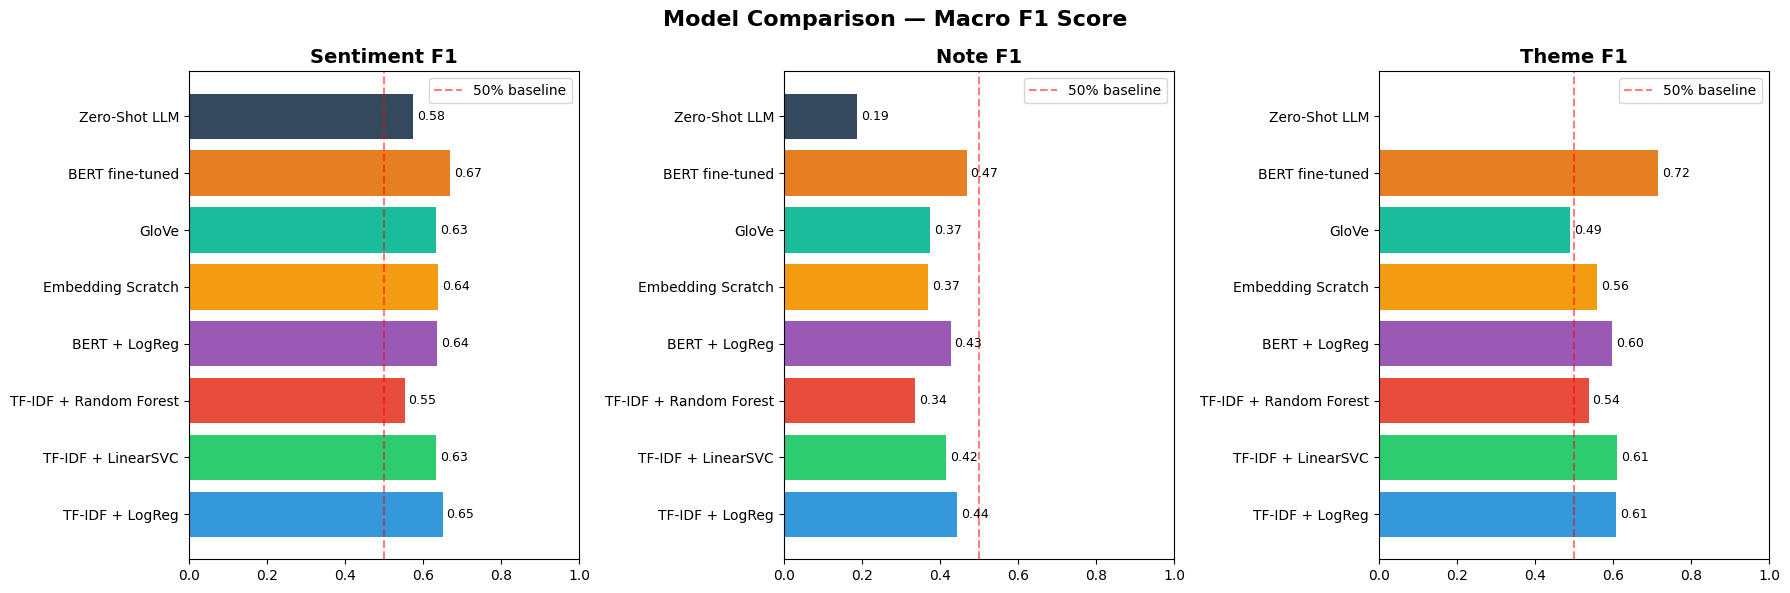

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Fill with your actual scores ---
results = {
    'Model': [
        'TF-IDF + LogReg',
        'TF-IDF + LinearSVC',
        'TF-IDF + Random Forest',
        'BERT + LogReg',
        'Embedding Scratch',
        'GloVe',
        'BERT fine-tuned',
        'Zero-Shot LLM'
    ],
    'Sentiment F1': [0.6506, 0.6340, 0.5528, 0.6355, 0.6389, 0.6328, 0.6691, 0.5758],
    'Note F1':      [0.4440, 0.4157, 0.3360, 0.4273, 0.3698, 0.3746, 0.4685, 0.1875],
    'Theme F1':     [0.6077, 0.6116, 0.5377, 0.5987, 0.5601, 0.4899, 0.7158, 0]
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
tasks = ['Sentiment F1', 'Note F1', 'Theme F1']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#e67e22', '#34495e']

for ax, task in zip(axes, tasks):
    values = df_results[task].fillna(0)
    bars = ax.barh(df_results['Model'], values, color=colors)

    ax.set_title(task, fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)

    # Reference baseline at 0.5
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='50% baseline')

    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                   f'{val:.2f}', va='center', fontsize=9)

    ax.legend()

plt.suptitle('Model Comparison — Macro F1 Score', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Export
Final dataset saved with all predictions for use in the Streamlit applications.

In [ ]:
import pandas as pd

df_final = pd.read_csv("avis_avec_themes.csv")

def note_to_sentiment(note):
    if note <= 2: return 'negative'
    elif note == 3: return 'neutral'
    else: return 'positive'

df_final['sentiment'] = df_final['note'].apply(note_to_sentiment)

df_final.to_csv("final_insurance_analysis_results.csv", index=False)
print("✅ Fichier final sauvegardé !")
print(f"Colonnes disponibles : {df_final.columns.tolist()}")
print(f"Shape : {df_final.shape}")

✅ Fichier final sauvegardé !
Colonnes disponibles : ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en', 'sentiment', 'avis_nllb_en', 'sentiment_score', 'theme']
Shape : (24104, 15)


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("avis_avec_themes.csv")
df = df.dropna(subset=['note', 'avis_nllb_en']).reset_index(drop=True)

def note_to_sentiment(note):
    if note <= 2: return 'negative'
    elif note == 3: return 'neutral'
    else: return 'positive'

df['sentiment'] = df['note'].apply(note_to_sentiment)

embeddings = np.load("avis_embeddings.npy")

print(f"✅ Dataset : {df.shape}")
print(f"✅ Embeddings : {embeddings.shape}")
print(f"✅ Colonnes : {df.columns.tolist()}")

✅ Dataset : (24104, 15)
✅ Embeddings : (24104, 384)
✅ Colonnes : ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en', 'sentiment', 'avis_nllb_en', 'sentiment_score', 'theme']


In [ ]:
from google.colab import files
import zipfile
import os

# Uploader les zips
uploaded = files.upload()  # Sélectionne les 3 zips

# Dézipper
for task in ['sentiment', 'note', 'theme']:
    zip_name = f"model_{task}.zip"
    if os.path.exists(zip_name):
        with zipfile.ZipFile(zip_name, 'r') as z:
            z.extractall(f"./model_{task}/best_model")
        print(f"✅ model_{task} restauré !")

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import json

for task in ['sentiment', 'note', 'theme']:
    model = AutoModelForSequenceClassification.from_pretrained(f"./model_{task}/best_model")
    tokenizer = AutoTokenizer.from_pretrained(f"./model_{task}/best_model")
    with open(f"./model_{task}/best_model/label_mapping.json") as f:
        labels = json.load(f)
    print(f"✅ {task} — {len(labels)} classes : {list(labels.values())}")